In [1]:
# 1. Clone the repository
!git clone https://github.com/iamkaleemsajjad-hue/Aether.git /kaggle/working/aether
%cd /kaggle/working/aether

# 2. Install Aether from cloned source in editable mode with PyTorch extra
!pip install -q -e ".[pytorch]"

# 3. Install benchmark measurement dependencies (matplotlib, pandas, etc.)
!pip install -q -r benchmark/requirements.txt


Cloning into '/kaggle/working/aether'...
remote: Enumerating objects: 2629, done.
remote: Counting objects: 100% (424/424), done.
remote: Compressing objects: 100% (225/225), done.
remote: Total 2629 (delta 273), reused 312 (delta 186), pack-reused 2205 (from 1)
Receiving objects: 100% (2629/2629), 12.51 MiB | 25.11 MiB/s, done.
Resolving deltas: 100% (1696/1696), done.
/kaggle/working/aether
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 1.4 MB/s eta 0:00:00a 0:00:01
  Building editable for aether-runtime (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ypy-websocket 0.8.4 requires aiofiles<23,>=22.1.0, but you have aiofi

In [2]:
%cd /kaggle/working/aether

import sys
# 1. Ensure the cloned source 'src' is first in sys.path in the Jupyter kernel
if "/kaggle/working/aether/src" not in sys.path:
    sys.path.insert(0, "/kaggle/working/aether/src")

# 2. Clear namespace package cache if aether was imported before sys.path was set
if "aether" in sys.modules and getattr(sys.modules["aether"], "__file__", None) is None:
    del sys.modules["aether"]

import torch
import aether

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU device count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i}: {p.name} | VRAM: {p.total_memory/1024**3:.1f} GiB | Compute: sm_{p.major}{p.minor}")

print(f"Aether path     : {aether.__file__}")
assert aether.__file__ and "/kaggle/working/aether" in aether.__file__, "Aether must be loaded from cloned source!"
print("\n[OK] Environment verified.")


/kaggle/working/aether
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU device count: 2
  cuda:0: Tesla T4 | VRAM: 14.6 GiB | Compute: sm_75
  cuda:1: Tesla T4 | VRAM: 14.6 GiB | Compute: sm_75
Aether path     : /kaggle/working/aether/src/aether/__init__.py

[OK] Environment verified.


In [3]:
%cd /kaggle/working/aether

!python benchmark.py \
    --smoke \
    --output-dir /kaggle/working/bench_smoke


/kaggle/working/aether
Multi-engine inference benchmark - suite 2.0.0

Hardware: cuda, 2 accelerator(s) present, 2 physical cores
  cuda:0  Tesla T4  14.6 GiB  sm_75
  cuda:1  Tesla T4  14.6 GiB  sm_75
Accelerators visible to each engine: 1 (every engine sees the same device, so no runtime is measured on more hardware than another)
Precision: fp16
  CUDA device (compute capability 7.5, 7.5) has no bf16 tensor-core path; bf16 needs 8.0 or
  newer. torch reports bf16 as supported here, but that is software emulation rather than a
  tensor-core path. Engines in this field refuse bf16 below 8.0 outright, so choosing it would
  exclude them rather than measure them. fp16 is the widest format every engine here executes
  natively. The checkpoints are published in bf16, so each engine holds its own 16-bit rendering
  of the same source values; that storage difference is recorded next to every comparison. Pass
  --precision bf16 for the weight-exact configuration, at the cost of the engines th

In [4]:
%cd /kaggle/working/aether

!python benchmark.py \
    --output-dir /kaggle/working/benchmark_results


/kaggle/working/aether
Multi-engine inference benchmark - suite 2.0.0

Hardware: cuda, 2 accelerator(s) present, 2 physical cores
  cuda:0  Tesla T4  14.6 GiB  sm_75
  cuda:1  Tesla T4  14.6 GiB  sm_75
Accelerators visible to each engine: 1 (every engine sees the same device, so no runtime is measured on more hardware than another)
Precision: fp16
  CUDA device (compute capability 7.5, 7.5) has no bf16 tensor-core path; bf16 needs 8.0 or
  newer. torch reports bf16 as supported here, but that is software emulation rather than a
  tensor-core path. Engines in this field refuse bf16 below 8.0 outright, so choosing it would
  exclude them rather than measure them. fp16 is the widest format every engine here executes
  natively. The checkpoints are published in bf16, so each engine holds its own 16-bit rendering
  of the same source values; that storage difference is recorded next to every comparison. Pass
  --precision bf16 for the weight-exact configuration, at the cost of the engines th

In [5]:
from IPython.display import Markdown, display
from pathlib import Path

report_path = Path("/kaggle/working/benchmark_results/reports/BENCHMARK_REPORT.md")
if not report_path.exists():
    report_path = Path("/kaggle/working/bench_smoke/reports/BENCHMARK_REPORT.md")

if report_path.exists():
    display(Markdown(report_path.read_text(encoding="utf-8")))
else:
    print("Report file not found. Check the output directory.")


# Inference Engine Benchmark Report

Generated: 2026-09-14T14:48:39.788751+00:00  
Suite version: 2.0.0  
Benchmark precision: fp16  
Accelerators visible to each engine: 1  
Models: 3  Engines attempted: 3

This report compares inference **stacks** executing the same model architectures and the same weights. The stacks are not all the same kind of system - some are frameworks, some are runtimes, some are graph compilers, some are serving engines - and the section below classifies each one, because the comparison only means what it says if the reader knows what is being compared.

Every engine is scored by the same code. The standings, the rankings and the pairwise matrix are computed for each engine identically, and no engine occupies a privileged position in any of them. The suite lives in the Aether Runtime repository, which is why Aether is in the field; it is not why any number here comes out the way it does, and where Aether loses the report says so in the same words it uses when Aether wins.

## Executive summary

1. **Best overall across the matrix**: **aether** - median 100% of the fastest engine in each cell, winning 100% of its 54 pairings.
2. **Fastest single cell anywhere in the matrix**: **aether** (1,562.72 tok/s on GPTNeo350M-Instruct-SFT).
3. **Fastest at batch 1** (the single-user case): **aether** (110.77 tok/s on GPTNeo350M-Instruct-SFT).
4. **Best batch scaling**: **transformers** at 95% of linear scaling up to batch 16 on SmolLM2-135M-Instruct.
5. **Lowest time to first token**: **aether** (0.022s on GPTNeo350M-Instruct-SFT).
6. **Lowest single-request latency**: **aether** (1.156s on GPTNeo350M-Instruct-SFT).
7. **Lowest peak memory**: **aether** (1.615 GiB on SmolLM2-135M-Instruct).
8. **Fastest cold start**: **aether** (1.415s on GPTNeo350M-Instruct-SFT).
9. **Closest competitions**: 12 within 1%, 53 within 5%, 54 within 10% of 162 ordered pairings.
10. **Compilation trade-off**: on SmolLM2-135M-Instruct, aether costs 7.7s more to start than transformers and saves 1957.8ms per request, so it pulls ahead after about 4 requests (build 7.0s, start-up 9.9s against 2.2s, per request 2.772s against 4.729s).

Every one of those is a different workload, and the engine that wins one does not necessarily win another. The standings below score the whole matrix; the per-workload rankings are at the end of the report.

| Rank | Engine | % of best (median) | W/L/T | Win rate | Median difference vs field | Cells measured | Same-representation pairings |
|---|---|---|---|---|---|---|---|
| 1 | `aether` | 100% | 54/0/0 | 100% | +99.2% | 27 | 54/54 |
| 2 | `transformers` | 51% | 14/27/13 | 26% | -6.7% | 27 | 54/54 |
| 3 | `pytorch_native` | 49% | 0/40/14 | 0% | -8.7% | 27 | 54/54 |



## What each system is

Not all of these are compilers, and the ones that compile do not all leave the same thing behind. The last column is the basis of the compile-once section: `portable-artifact` means a file or directory another process can load; `on-disk-cache` means machine-local generated code keyed to the library, the device and the graph; `process-local` means the work is redone on every start; `none` means there is no build phase at all.

| Key | System | Classification | Build phase | What the build leaves |
|---|---|---|---|---|
| `transformers` | HF Transformers (PyTorch eager) | inference framework, runtime | no | none |
| `pytorch_native` | PyTorch native decode loop | runtime, execution engine | no | none |
| `aether` | Aether Runtime | AOT compiler, graph compiler, runtime, execution engine | yes | portable-artifact |



## Methodology

One variable is intended to change between rows: the inference stack. Everything else is held fixed and recorded.

**Held fixed**

- **Model and weights.** The same repository at the same revision for every engine. Revisions are listed per model below.
- **Precision.** fp16 for every engine. Chosen because: CUDA device (compute capability 7.5, 7.5) has no bf16 tensor-core path; bf16 needs 8.0 or newer. torch reports bf16 as supported here, but that is software emulation rather than a tensor-core path. Engines in this field refuse bf16 below 8.0 outright, so choosing it would exclude them rather than measure them. fp16 is the widest format every engine here executes natively. The checkpoints are published in bf16, so each engine holds its own 16-bit rendering of the same source values; that storage difference is recorded next to every comparison. Pass --precision bf16 for the weight-exact configuration, at the cost of the engines that cannot run it.
- **Prompts.** Built once per model, before any engine starts, to an exact token count using that model's own tokenizer, then handed to every engine as the identical string. Each engine's tokenizer is then checked against the prompt-builder's, and any disagreement is reported in the compatibility table.
- **Generation settings.** max_new_tokens per cell as tabulated; temperature 0.0, top_p 1.0, top_k 0, seed 1234. Every engine is asked for a fixed number of tokens with early stopping suppressed, so no engine can appear faster by generating less.
- **Threads.** Pinned to 2 for every engine, and set in OMP, MKL, OpenBLAS, NumExpr and torch before any library initializes.
- **Accelerators.** Each engine saw 1 device(s), enforced by restricting visibility in the worker before any CUDA context was created. No engine's placement logic was modified; each simply found that many devices. This is what stops a runtime that shards from being measured on more hardware than one that does not.
- **Iterations.** 3 warm-up iterations, executed and discarded, then 10 measured iterations per cell. The first unwarmed call is reported separately as cold latency and is never averaged into steady state.

**How each measurement is taken**

- Every engine runs in its own process. One engine's failure, memory reservation or crash cannot affect another's numbers, and peak process memory is attributable to exactly one engine.
- Only one worker runs at a time. Concurrent workers would contend for cores, memory bandwidth and the device, and every number would measure the contention.
- Engine order is rotated per model, so a host that drifts thermally over a long run does not always penalize the same engine. The order used is recorded.
- CUDA is synchronized on both edges of every timed region, so no asynchronous kernel is attributed to the wrong phase.
- Device telemetry is sampled in dedicated extra iterations, never during the iterations whose latency is reported.
- Download, build/compile, load, warm-up and steady state are timed as separate phases and never combined into one figure.

**What each metric means**

| Metric | Definition |
|---|---|
| generation throughput (tok/s, whole request) | generated tokens times batch width, divided by the wall time of the whole generation call including prefill. Defined for every engine, which is why headline comparisons use it. |
| decode tok/s | measured end-to-end latency minus measured prefill, over the tokens the decode loop produced. Carries the uncertainty of both measurements, and is only reported where the engine exposes a prefill path. |
| prompt tok/s | prompt tokens divided by measured prefill time. |
| TTFT | time until the first token is available to a caller. The method differs by engine (a real token stream, or a one-token generation call) and each engine's method is stated. |
| TPOT / ITL | decode seconds divided by the tokens the decode loop produced; the average gap between consecutive tokens. |
| scaling efficiency | batch-N throughput divided by (batch-1 throughput times N), as a percentage. 100% is perfectly linear. |
| per-request tok/s | aggregate throughput divided by batch width: what one caller inside the batch experiences. |
| peak host / device memory | process resident set size sampled during inference, and the allocator's peak reserved bytes. |



## Environment

| Property | Value |
|---|---|
| GPU count | 2 |
| GPU(s) | Tesla T4, Tesla T4 |
| GPU VRAM | 14.562 GiB, 14.562 GiB |
| Compute capability | 7.5, 7.5 |
| CUDA runtime (torch) | 12.8 |
| cuDNN | 91,002 |
| SDPA backends enabled | {'flash': True, 'mem_efficient': True, 'math': True} |
| nvidia-smi | 0, Tesla T4, 580.159.04, 15360 MiB, 52, 70.00 W, 1590 MHz<br>1, Tesla T4, 580.159.04, 15360 MiB, 40, 70.00 W, 1590 MHz |
| CPU | Intel(R) Xeon(R) CPU @ 2.00GHz |
| CPU cores (physical/logical) | 2 / 4 |
| torch threads | 2 |
| System RAM total | 31.348 GiB |
| System RAM available | 29.181 GiB |
| OS | Linux-6.12.90+-x86_64-with-glibc2.35 |
| Python | 3.12.13 |
| PyTorch | 2.10.0+cu128 |
| Transformers | 5.0.0 |
| Tokenizers | 0.22.2 |
| Aether Runtime | 1.2.8a0 |
| Aether commit | aadaaa8a28972925b17825ce9bb3b23fbf1bdd2c |
| Aether working tree dirty | no |


**Model revisions** (both backends load these exact commits):

| Model | Revision |
|---|---|
| HuggingFaceTB/SmolLM2-135M-Instruct | 12fd25f77366fa6b3b4b768ec3050bf629380bac |
| Qwen/Qwen3-0.6B | c1899de289a04d12100db370d81485cdf75e47ca |
| SummerSigh/GPTNeo350M-Instruct-SFT | 41ffbc30deb85c1f54a12f95dccc197642cf8752 |


**Relevant environment variables:**

| Variable | Value |
|---|---|
| KAGGLE_KERNEL_RUN_TYPE | Interactive |


**Benchmark-controlled environment**

| Property | Value |
|---|---|
| Accelerator class | cuda |
| Accelerators present | 2 |
| Compute capability | 7.5, 7.5 |
| bf16 tensor cores (capability >= 8.0) | no |
| Native fp16 on this device | yes |
| Benchmark precision | fp16 |
| Precision chosen because | CUDA device (compute capability 7.5, 7.5) has no bf16 tensor-core path; bf16 needs 8.0 or newer. torch reports bf16 as supported here, but that is software emulation rather than a tensor-core path. Engines in this field refuse bf16 below 8.0 outright, so choosing it would exclude them rather than measure them. fp16 is the widest format every engine here executes natively. The checkpoints are published in bf16, so each engine holds its own 16-bit rendering of the same source values; that storage difference is recorded next to every comparison. Pass --precision bf16 for the weight-exact configuration, at the cost of the engines that cannot run it |
| Threads pinned to | 2 |
| Accelerators visible per engine | 1 |
| Native bf16 per torch | yes |
| Suite version | 2.0.0 |
| Invocation | `benchmark.py --output-dir /kaggle/working/benchmark_results` |



## Engine compatibility

A status other than MEASURED is a fact about this host or this model, not a performance result. `NOT_APPLICABLE` means the engine could never run here; `NOT_INSTALLED` means it is absent; `NOT_SUPPORTED` means it is present but cannot execute this configuration; `FAILED` means it tried and raised. None of them is a zero.

| Engine | Model | Status | Version | Cells | Representation | Tokenizer matches | Reason |
|---|---|---|---|---|---|---|---|
| `transformers` | SmolLM2-135M-Instruct | MEASURED | 5.0.0 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |
| `pytorch_native` | SmolLM2-135M-Instruct | MEASURED | 2.10.0+cu128 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |
| `aether` | SmolLM2-135M-Instruct | MEASURED | 1.2.8a0 | 9/9 | compiled AEG artifact, bf16 weight storage, fp16 compute | yes |  |
| `pytorch_native` | Qwen3-0.6B | MEASURED | 2.10.0+cu128 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |
| `aether` | Qwen3-0.6B | MEASURED | 1.2.8a0 | 9/9 | compiled AEG artifact, bf16 weight storage, fp16 compute | yes |  |
| `transformers` | Qwen3-0.6B | MEASURED | 5.0.0 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |
| `aether` | GPTNeo350M-Instruct-SFT | MEASURED | 1.2.8a0 | 9/9 | compiled AEG artifact, bf16 weight storage, fp16 compute | yes |  |
| `transformers` | GPTNeo350M-Instruct-SFT | MEASURED | 5.0.0 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | MEASURED | 2.10.0+cu128 | 9/9 | published checkpoint cast to fp16 tensors | yes |  |



## Who won each cell

The fastest engine in every measured configuration, and how far ahead of the runner-up it was. `engines` is how many produced a comparable measurement there - a cell with fewer engines is an easier cell to lead.

| Model | Batch | Workload | Fastest | tok/s | Runner-up | tok/s | Margin | Engines |
|---|---|---|---|---|---|---|---|---|
| SmolLM2-135M-Instruct | b1 | p32/o128 | **aether** | 44.93 | `pytorch_native` | 27.30 | +64.6% | 3 |
| SmolLM2-135M-Instruct | b1 | p256/o32 | **aether** | 42.75 | `transformers` | 27.16 | +57.4% | 3 |
| SmolLM2-135M-Instruct | b1 | p256/o128 | **aether** | 46.18 | `pytorch_native` | 27.32 | +69.1% | 3 |
| SmolLM2-135M-Instruct | b1 | p256/o512 | **aether** | 48.07 | `pytorch_native` | 27.45 | +75.1% | 3 |
| SmolLM2-135M-Instruct | b1 | p1024/o128 | **aether** | 46.94 | `pytorch_native` | 27.00 | +73.8% | 3 |
| SmolLM2-135M-Instruct | b2 | p256/o128 | **aether** | 85.74 | `transformers` | 52.91 | +62.0% | 3 |
| SmolLM2-135M-Instruct | b4 | p256/o128 | **aether** | 178.19 | `transformers` | 105.85 | +68.3% | 3 |
| SmolLM2-135M-Instruct | b8 | p256/o128 | **aether** | 355.94 | `transformers` | 210.49 | +69.1% | 3 |
| SmolLM2-135M-Instruct | b16 | p256/o128 | **aether** | 674.99 | `transformers` | 413.00 | +63.4% | 3 |
| Qwen3-0.6B | b1 | p32/o128 | **aether** | 48.34 | `transformers` | 22.53 | +114.6% | 3 |
| Qwen3-0.6B | b1 | p256/o32 | **aether** | 44.30 | `transformers` | 22.81 | +94.2% | 3 |
| Qwen3-0.6B | b1 | p256/o128 | **aether** | 48.21 | `transformers` | 23.01 | +109.5% | 3 |
| Qwen3-0.6B | b1 | p256/o512 | **aether** | 50.37 | `transformers` | 22.49 | +124.0% | 3 |
| Qwen3-0.6B | b1 | p1024/o128 | **aether** | 46.10 | `transformers` | 22.11 | +108.5% | 3 |
| Qwen3-0.6B | b2 | p256/o128 | **aether** | 82.63 | `transformers` | 44.86 | +84.2% | 3 |
| Qwen3-0.6B | b4 | p256/o128 | **aether** | 165.54 | `transformers` | 88.96 | +86.1% | 3 |
| Qwen3-0.6B | b8 | p256/o128 | **aether** | 234.55 | `transformers` | 171.74 | +36.6% | 3 |
| Qwen3-0.6B | b16 | p256/o128 | **aether** | 273.35 | `transformers` | 241.03 | +13.4% | 3 |
| GPTNeo350M-Instruct-SFT | b1 | p32/o128 | **aether** | 112.92 | `pytorch_native` | 40.04 | +182.0% | 3 |
| GPTNeo350M-Instruct-SFT | b1 | p256/o32 | **aether** | 102.20 | `transformers` | 40.88 | +150.0% | 3 |
| GPTNeo350M-Instruct-SFT | b1 | p256/o128 | **aether** | 110.77 | `transformers` | 41.27 | +168.4% | 3 |
| GPTNeo350M-Instruct-SFT | b1 | p256/o512 | **aether** | 116.76 | `transformers` | 41.05 | +184.5% | 3 |
| GPTNeo350M-Instruct-SFT | b1 | p1024/o128 | **aether** | 116.15 | `transformers` | 39.78 | +192.0% | 3 |
| GPTNeo350M-Instruct-SFT | b2 | p256/o128 | **aether** | 206.79 | `transformers` | 83.82 | +146.7% | 3 |
| GPTNeo350M-Instruct-SFT | b4 | p256/o128 | **aether** | 447.40 | `transformers` | 165.86 | +169.7% | 3 |
| GPTNeo350M-Instruct-SFT | b8 | p256/o128 | **aether** | 849.21 | `transformers` | 303.24 | +180.0% | 3 |
| GPTNeo350M-Instruct-SFT | b16 | p256/o128 | **aether** | 1,562.72 | `transformers` | 489.17 | +219.5% | 3 |


### Pairwise matrix

Median difference of the row engine against the column engine, over every cell both measured. Positive means the row engine was faster. Every pairing appears in both directions, so the matrix is anti-symmetric by construction and no engine holds a privileged position in it.

| Engine | vs aether | vs pytorch_native | vs transformers |
|---|---|---|---|
| `aether` | — | +104.3% | +94.2% |
| `pytorch_native` | -51.0% | — | -2.0% |
| `transformers` | -48.5% | +2.0% | — |



## Model-by-model results

### HuggingFaceTB/SmolLM2-135M-Instruct

| Property | Value |
|---|---|
| Model id | `HuggingFaceTB/SmolLM2-135M-Instruct` |
| Revision | 12fd25f77366fa6b3b4b768ec3050bf629380bac |
| Architecture | LlamaForCausalLM |
| Parameters | 134,515,008 |
| Layers / hidden / heads / KV heads | 30 / 576 / 9 / 3 |
| Vocabulary | 49,152 |
| Declared context length | 8,192 |
| Checkpoint dtype | torch.bfloat16 |
| Tokenizer | TokenizersBackend |
| Tokenizer vocabulary | 49,152 |
| Fits smallest visible device | yes |
| Engine order used | transformers, pytorch_native, aether |


#### Batch 1 - the single-request case

| Engine | Status | tok/s | decode tok/s | prompt tok/s | TTFT | TPOT | latency | peak memory | samples |
|---|---|---|---|---|---|---|---|---|---|
| `aether` | MEASURED | 46.18 | 46.30 | 8,905.61 | 0.052s | 21.60 ms | 2.772s | 0.633 GiB | n=10 cv=0.025 |
| `pytorch_native` | MEASURED | 27.32 | 27.35 | 6,175.01 | 0.040s | 36.57 ms | 4.686s | 0.318 GiB | n=10 cv=0.012 |
| `transformers` | MEASURED | 27.06 | 27.10 | 6,004.59 | 0.043s | 36.90 ms | 4.729s | 0.295 GiB | n=10 cv=0.006 |


#### Batch scaling

| Engine | Batch | Support | batch tok/s | per-request tok/s | vs batch 1 | scaling efficiency | latency |
|---|---|---|---|---|---|---|---|
| `aether` | 1 | SUPPORTED | 46.18 | 46.18 | 1.00x | 100% | 2.772s |
| `aether` | 2 | SUPPORTED | 85.74 | 42.87 | 1.86x | 93% | 2.986s |
| `aether` | 4 | SUPPORTED | 178.19 | 44.55 | 3.86x | 96% | 2.873s |
| `aether` | 8 | SUPPORTED | 355.94 | 44.49 | 7.71x | 96% | 2.877s |
| `aether` | 16 | SUPPORTED | 674.99 | 42.19 | 14.62x | 91% | 3.034s |
| `pytorch_native` | 1 | SUPPORTED | 27.32 | 27.32 | 1.00x | 100% | 4.686s |
| `pytorch_native` | 2 | SUPPORTED | 52.90 | 26.45 | 1.94x | 97% | 4.839s |
| `pytorch_native` | 4 | SUPPORTED | 105.23 | 26.31 | 3.85x | 96% | 4.866s |
| `pytorch_native` | 8 | SUPPORTED | 208.09 | 26.01 | 7.62x | 95% | 4.921s |
| `pytorch_native` | 16 | SUPPORTED | 410.20 | 25.64 | 15.02x | 94% | 4.993s |
| `transformers` | 1 | SUPPORTED | 27.06 | 27.06 | 1.00x | 100% | 4.729s |
| `transformers` | 2 | SUPPORTED | 52.91 | 26.45 | 1.95x | 98% | 4.838s |
| `transformers` | 4 | SUPPORTED | 105.85 | 26.46 | 3.91x | 98% | 4.837s |
| `transformers` | 8 | SUPPORTED | 210.49 | 26.31 | 7.78x | 97% | 4.865s |
| `transformers` | 16 | SUPPORTED | 413.00 | 25.81 | 15.26x | 95% | 4.959s |


#### Prompt-length and output-length sweeps

| Engine | Prompt tokens | Output tokens | Status | tok/s | latency | cold first call |
|---|---|---|---|---|---|---|
| `aether` | 32 | 128 | MEASURED | 44.93 | 2.849s | 2.704s |
| `aether` | 256 | 32 | MEASURED | 42.75 | 0.749s | 0.764s |
| `aether` | 256 | 128 | MEASURED | 46.18 | 2.772s | 2.974s |
| `aether` | 256 | 512 | MEASURED | 48.07 | 10.651s | 10.894s |
| `aether` | 1024 | 128 | MEASURED | 46.94 | 2.727s | 2.780s |
| `pytorch_native` | 32 | 128 | MEASURED | 27.30 | 4.688s | 5.137s |
| `pytorch_native` | 256 | 32 | MEASURED | 26.62 | 1.202s | 1.193s |
| `pytorch_native` | 256 | 128 | MEASURED | 27.32 | 4.686s | 5.175s |
| `pytorch_native` | 256 | 512 | MEASURED | 27.45 | 18.651s | 18.663s |
| `pytorch_native` | 1024 | 128 | MEASURED | 27.00 | 4.740s | 4.755s |
| `transformers` | 32 | 128 | MEASURED | 27.24 | 4.700s | 4.652s |
| `transformers` | 256 | 32 | MEASURED | 27.16 | 1.178s | 1.223s |
| `transformers` | 256 | 128 | MEASURED | 27.06 | 4.729s | 5.238s |
| `transformers` | 256 | 512 | MEASURED | 27.05 | 18.927s | 18.925s |
| `transformers` | 1024 | 128 | MEASURED | 26.59 | 4.815s | 4.873s |


#### Aether against each engine on this model

| Cell | Rank | Engine | tok/s | Compared against | Difference |
|---|---|---|---|---|---|
| b1 p32 o128 | 1 | `aether` | 44.93 | `pytorch_native` | +64.6% |
| b1 p32 o128 | 2 | `pytorch_native` | 27.30 | `aether` | -39.2% |
| b1 p32 o128 | 3 | `transformers` | 27.24 | `aether` | -39.4% |
| b1 p256 o32 | 1 | `aether` | 42.75 | `transformers` | +57.4% |
| b1 p256 o32 | 2 | `transformers` | 27.16 | `aether` | -36.5% |
| b1 p256 o32 | 3 | `pytorch_native` | 26.62 | `aether` | -37.7% |
| b1 p256 o128 | 1 | `aether` | 46.18 | `pytorch_native` | +69.1% |
| b1 p256 o128 | 2 | `pytorch_native` | 27.32 | `aether` | -40.8% |
| b1 p256 o128 | 3 | `transformers` | 27.06 | `aether` | -41.4% |
| b1 p256 o512 | 1 | `aether` | 48.07 | `pytorch_native` | +75.1% |
| b1 p256 o512 | 2 | `pytorch_native` | 27.45 | `aether` | -42.9% |
| b1 p256 o512 | 3 | `transformers` | 27.05 | `aether` | -43.7% |
| b1 p1024 o128 | 1 | `aether` | 46.94 | `pytorch_native` | +73.8% |
| b1 p1024 o128 | 2 | `pytorch_native` | 27.00 | `aether` | -42.5% |
| b1 p1024 o128 | 3 | `transformers` | 26.59 | `aether` | -43.4% |
| b2 p256 o128 | 1 | `aether` | 85.74 | `transformers` | +62.0% |
| b2 p256 o128 | 2 | `transformers` | 52.91 | `aether` | -38.3% |
| b2 p256 o128 | 3 | `pytorch_native` | 52.90 | `aether` | -38.3% |
| b4 p256 o128 | 1 | `aether` | 178.19 | `transformers` | +68.3% |
| b4 p256 o128 | 2 | `transformers` | 105.85 | `aether` | -40.6% |
| b4 p256 o128 | 3 | `pytorch_native` | 105.23 | `aether` | -40.9% |
| b8 p256 o128 | 1 | `aether` | 355.94 | `transformers` | +69.1% |
| b8 p256 o128 | 2 | `transformers` | 210.49 | `aether` | -40.9% |
| b8 p256 o128 | 3 | `pytorch_native` | 208.09 | `aether` | -41.5% |
| b16 p256 o128 | 1 | `aether` | 674.99 | `transformers` | +63.4% |
| b16 p256 o128 | 2 | `transformers` | 413.00 | `aether` | -38.8% |
| b16 p256 o128 | 3 | `pytorch_native` | 410.20 | `aether` | -39.2% |


![01_throughput_ranking__SmolLM2-135M-Instruct.png](../graphs/01_throughput_ranking__SmolLM2-135M-Instruct.png)
![02_batch_scaling__SmolLM2-135M-Instruct.png](../graphs/02_batch_scaling__SmolLM2-135M-Instruct.png)
![03_scaling_efficiency__SmolLM2-135M-Instruct.png](../graphs/03_scaling_efficiency__SmolLM2-135M-Instruct.png)
![04_batch1__SmolLM2-135M-Instruct.png](../graphs/04_batch1__SmolLM2-135M-Instruct.png)
![05_ttft__SmolLM2-135M-Instruct.png](../graphs/05_ttft__SmolLM2-135M-Instruct.png)
![06_memory_host__SmolLM2-135M-Instruct.png](../graphs/06_memory_host__SmolLM2-135M-Instruct.png)
![06b_memory_device__SmolLM2-135M-Instruct.png](../graphs/06b_memory_device__SmolLM2-135M-Instruct.png)
![09_prompt_length__SmolLM2-135M-Instruct.png](../graphs/09_prompt_length__SmolLM2-135M-Instruct.png)
![10_output_length__SmolLM2-135M-Instruct.png](../graphs/10_output_length__SmolLM2-135M-Instruct.png)

### Qwen/Qwen3-0.6B

| Property | Value |
|---|---|
| Model id | `Qwen/Qwen3-0.6B` |
| Revision | c1899de289a04d12100db370d81485cdf75e47ca |
| Architecture | Qwen3ForCausalLM |
| Parameters | 751,632,384 |
| Layers / hidden / heads / KV heads | 28 / 1,024 / 16 / 8 |
| Vocabulary | 151,936 |
| Declared context length | 40,960 |
| Checkpoint dtype | torch.bfloat16 |
| Tokenizer | Qwen2Tokenizer |
| Tokenizer vocabulary | 151,669 |
| Fits smallest visible device | yes |
| Engine order used | pytorch_native, aether, transformers |


#### Batch 1 - the single-request case

| Engine | Status | tok/s | decode tok/s | prompt tok/s | TTFT | TPOT | latency | peak memory | samples |
|---|---|---|---|---|---|---|---|---|---|
| `aether` | MEASURED | 48.21 | 48.47 | 7,301.45 | 0.050s | 20.63 ms | 2.655s | 2.277 GiB | n=10 cv=0.020 |
| `transformers` | MEASURED | 23.01 | 23.03 | 5,214.71 | 0.050s | 43.42 ms | 5.563s | 1.502 GiB | n=10 cv=0.007 |
| `pytorch_native` | MEASURED | 21.93 | 21.95 | 5,043.07 | 0.050s | 45.55 ms | 5.836s | 1.576 GiB | n=10 cv=0.006 |


#### Batch scaling

| Engine | Batch | Support | batch tok/s | per-request tok/s | vs batch 1 | scaling efficiency | latency |
|---|---|---|---|---|---|---|---|
| `aether` | 1 | SUPPORTED | 48.21 | 48.21 | 1.00x | 100% | 2.655s |
| `aether` | 2 | SUPPORTED | 82.63 | 41.31 | 1.71x | 86% | 3.098s |
| `aether` | 4 | SUPPORTED | 165.54 | 41.38 | 3.43x | 86% | 3.093s |
| `aether` | 8 | SUPPORTED | 234.55 | 29.32 | 4.87x | 61% | 4.366s |
| `aether` | 16 | SUPPORTED | 273.35 | 17.08 | 5.67x | 35% | 7.492s |
| `pytorch_native` | 1 | SUPPORTED | 21.93 | 21.93 | 1.00x | 100% | 5.836s |
| `pytorch_native` | 2 | SUPPORTED | 43.39 | 21.69 | 1.98x | 99% | 5.900s |
| `pytorch_native` | 4 | SUPPORTED | 85.60 | 21.40 | 3.90x | 98% | 5.981s |
| `pytorch_native` | 8 | SUPPORTED | 165.88 | 20.74 | 7.56x | 95% | 6.173s |
| `pytorch_native` | 16 | SUPPORTED | 239.23 | 14.95 | 10.91x | 68% | 8.561s |
| `transformers` | 1 | SUPPORTED | 23.01 | 23.01 | 1.00x | 100% | 5.563s |
| `transformers` | 2 | SUPPORTED | 44.86 | 22.43 | 1.95x | 97% | 5.707s |
| `transformers` | 4 | SUPPORTED | 88.96 | 22.24 | 3.87x | 97% | 5.755s |
| `transformers` | 8 | SUPPORTED | 171.74 | 21.47 | 7.46x | 93% | 5.963s |
| `transformers` | 16 | SUPPORTED | 241.03 | 15.06 | 10.48x | 65% | 8.497s |


#### Prompt-length and output-length sweeps

| Engine | Prompt tokens | Output tokens | Status | tok/s | latency | cold first call |
|---|---|---|---|---|---|---|
| `aether` | 32 | 128 | MEASURED | 48.34 | 2.648s | 2.794s |
| `aether` | 256 | 32 | MEASURED | 44.30 | 0.722s | 0.713s |
| `aether` | 256 | 128 | MEASURED | 48.21 | 2.655s | 2.999s |
| `aether` | 256 | 512 | MEASURED | 50.37 | 10.164s | 10.682s |
| `aether` | 1024 | 128 | MEASURED | 46.10 | 2.777s | 2.778s |
| `pytorch_native` | 32 | 128 | MEASURED | 21.89 | 5.846s | 5.766s |
| `pytorch_native` | 256 | 32 | MEASURED | 21.69 | 1.476s | 1.499s |
| `pytorch_native` | 256 | 128 | MEASURED | 21.93 | 5.836s | 6.777s |
| `pytorch_native` | 256 | 512 | MEASURED | 22.22 | 23.042s | 22.943s |
| `pytorch_native` | 1024 | 128 | MEASURED | 21.52 | 5.947s | 6.018s |
| `transformers` | 32 | 128 | MEASURED | 22.53 | 5.681s | 5.644s |
| `transformers` | 256 | 32 | MEASURED | 22.81 | 1.403s | 1.419s |
| `transformers` | 256 | 128 | MEASURED | 23.01 | 5.563s | 6.141s |
| `transformers` | 256 | 512 | MEASURED | 22.49 | 22.766s | 22.365s |
| `transformers` | 1024 | 128 | MEASURED | 22.11 | 5.790s | 5.892s |


#### Aether against each engine on this model

| Cell | Rank | Engine | tok/s | Compared against | Difference |
|---|---|---|---|---|---|
| b1 p32 o128 | 1 | `aether` | 48.34 | `transformers` | +114.6% |
| b1 p32 o128 | 2 | `transformers` | 22.53 | `aether` | -53.4% |
| b1 p32 o128 | 3 | `pytorch_native` | 21.89 | `aether` | -54.7% |
| b1 p256 o32 | 1 | `aether` | 44.30 | `transformers` | +94.2% |
| b1 p256 o32 | 2 | `transformers` | 22.81 | `aether` | -48.5% |
| b1 p256 o32 | 3 | `pytorch_native` | 21.69 | `aether` | -51.0% |
| b1 p256 o128 | 1 | `aether` | 48.21 | `transformers` | +109.5% |
| b1 p256 o128 | 2 | `transformers` | 23.01 | `aether` | -52.3% |
| b1 p256 o128 | 3 | `pytorch_native` | 21.93 | `aether` | -54.5% |
| b1 p256 o512 | 1 | `aether` | 50.37 | `transformers` | +124.0% |
| b1 p256 o512 | 2 | `transformers` | 22.49 | `aether` | -55.4% |
| b1 p256 o512 | 3 | `pytorch_native` | 22.22 | `aether` | -55.9% |
| b1 p1024 o128 | 1 | `aether` | 46.10 | `transformers` | +108.5% |
| b1 p1024 o128 | 2 | `transformers` | 22.11 | `aether` | -52.0% |
| b1 p1024 o128 | 3 | `pytorch_native` | 21.52 | `aether` | -53.3% |
| b2 p256 o128 | 1 | `aether` | 82.63 | `transformers` | +84.2% |
| b2 p256 o128 | 2 | `transformers` | 44.86 | `aether` | -45.7% |
| b2 p256 o128 | 3 | `pytorch_native` | 43.39 | `aether` | -47.5% |
| b4 p256 o128 | 1 | `aether` | 165.54 | `transformers` | +86.1% |
| b4 p256 o128 | 2 | `transformers` | 88.96 | `aether` | -46.3% |
| b4 p256 o128 | 3 | `pytorch_native` | 85.60 | `aether` | -48.3% |
| b8 p256 o128 | 1 | `aether` | 234.55 | `transformers` | +36.6% |
| b8 p256 o128 | 2 | `transformers` | 171.74 | `aether` | -26.8% |
| b8 p256 o128 | 3 | `pytorch_native` | 165.88 | `aether` | -29.3% |
| b16 p256 o128 | 1 | `aether` | 273.35 | `transformers` | +13.4% |
| b16 p256 o128 | 2 | `transformers` | 241.03 | `aether` | -11.8% |
| b16 p256 o128 | 3 | `pytorch_native` | 239.23 | `aether` | -12.5% |


![01_throughput_ranking__Qwen3-0.6B.png](../graphs/01_throughput_ranking__Qwen3-0.6B.png)
![02_batch_scaling__Qwen3-0.6B.png](../graphs/02_batch_scaling__Qwen3-0.6B.png)
![03_scaling_efficiency__Qwen3-0.6B.png](../graphs/03_scaling_efficiency__Qwen3-0.6B.png)
![04_batch1__Qwen3-0.6B.png](../graphs/04_batch1__Qwen3-0.6B.png)
![05_ttft__Qwen3-0.6B.png](../graphs/05_ttft__Qwen3-0.6B.png)
![06_memory_host__Qwen3-0.6B.png](../graphs/06_memory_host__Qwen3-0.6B.png)
![06b_memory_device__Qwen3-0.6B.png](../graphs/06b_memory_device__Qwen3-0.6B.png)
![09_prompt_length__Qwen3-0.6B.png](../graphs/09_prompt_length__Qwen3-0.6B.png)
![10_output_length__Qwen3-0.6B.png](../graphs/10_output_length__Qwen3-0.6B.png)

### SummerSigh/GPTNeo350M-Instruct-SFT

| Property | Value |
|---|---|
| Model id | `SummerSigh/GPTNeo350M-Instruct-SFT` |
| Revision | 41ffbc30deb85c1f54a12f95dccc197642cf8752 |
| Architecture | GPTNeoForCausalLM |
| Parameters | 456,461,312 |
| Layers / hidden / heads / KV heads | 24 / 1,024 / 16 / — |
| Vocabulary | 50,257 |
| Declared context length | 2,048 |
| Checkpoint dtype | torch.float32 |
| Tokenizer | GPT2Tokenizer |
| Tokenizer vocabulary | 50,257 |
| Fits smallest visible device | yes |
| Engine order used | aether, transformers, pytorch_native |


#### Batch 1 - the single-request case

| Engine | Status | tok/s | decode tok/s | prompt tok/s | TTFT | TPOT | latency | peak memory | samples |
|---|---|---|---|---|---|---|---|---|---|
| `aether` | MEASURED | 110.77 | 111.06 | 21,016.21 | 0.022s | 9.00 ms | 1.156s | 1.143 GiB | n=10 cv=0.028 |
| `transformers` | MEASURED | 41.27 | 41.29 | 9,990.94 | 0.028s | 24.22 ms | 3.102s | 0.836 GiB | n=10 cv=0.013 |
| `pytorch_native` | MEASURED | 40.06 | 40.07 | 9,849.62 | 0.026s | 24.96 ms | 3.195s | 0.863 GiB | n=10 cv=0.009 |


#### Batch scaling

| Engine | Batch | Support | batch tok/s | per-request tok/s | vs batch 1 | scaling efficiency | latency |
|---|---|---|---|---|---|---|---|
| `aether` | 1 | SUPPORTED | 110.77 | 110.77 | 1.00x | 100% | 1.156s |
| `aether` | 2 | SUPPORTED | 206.79 | 103.39 | 1.87x | 93% | 1.238s |
| `aether` | 4 | SUPPORTED | 447.40 | 111.85 | 4.04x | 101% | 1.144s |
| `aether` | 8 | SUPPORTED | 849.21 | 106.15 | 7.67x | 96% | 1.206s |
| `aether` | 16 | SUPPORTED | 1,562.72 | 97.67 | 14.11x | 88% | 1.311s |
| `pytorch_native` | 1 | SUPPORTED | 40.06 | 40.06 | 1.00x | 100% | 3.195s |
| `pytorch_native` | 2 | SUPPORTED | 81.90 | 40.95 | 2.04x | 102% | 3.126s |
| `pytorch_native` | 4 | SUPPORTED | 161.17 | 40.29 | 4.02x | 101% | 3.177s |
| `pytorch_native` | 8 | SUPPORTED | 295.32 | 36.91 | 7.37x | 92% | 3.467s |
| `pytorch_native` | 16 | SUPPORTED | 476.01 | 29.75 | 11.88x | 74% | 4.302s |
| `transformers` | 1 | SUPPORTED | 41.27 | 41.27 | 1.00x | 100% | 3.102s |
| `transformers` | 2 | SUPPORTED | 83.82 | 41.91 | 2.03x | 102% | 3.054s |
| `transformers` | 4 | SUPPORTED | 165.86 | 41.47 | 4.02x | 100% | 3.087s |
| `transformers` | 8 | SUPPORTED | 303.24 | 37.90 | 7.35x | 92% | 3.377s |
| `transformers` | 16 | SUPPORTED | 489.17 | 30.57 | 11.85x | 74% | 4.187s |


#### Prompt-length and output-length sweeps

| Engine | Prompt tokens | Output tokens | Status | tok/s | latency | cold first call |
|---|---|---|---|---|---|---|
| `aether` | 32 | 128 | MEASURED | 112.92 | 1.134s | 1.190s |
| `aether` | 256 | 32 | MEASURED | 102.20 | 0.313s | 0.308s |
| `aether` | 256 | 128 | MEASURED | 110.77 | 1.156s | 1.415s |
| `aether` | 256 | 512 | MEASURED | 116.76 | 4.385s | 4.397s |
| `aether` | 1024 | 128 | MEASURED | 116.15 | 1.102s | 1.106s |
| `pytorch_native` | 32 | 128 | MEASURED | 40.04 | 3.196s | 3.374s |
| `pytorch_native` | 256 | 32 | MEASURED | 39.22 | 0.816s | 0.834s |
| `pytorch_native` | 256 | 128 | MEASURED | 40.06 | 3.195s | 3.652s |
| `pytorch_native` | 256 | 512 | MEASURED | 40.42 | 12.666s | 12.676s |
| `pytorch_native` | 1024 | 128 | MEASURED | 39.19 | 3.266s | 3.313s |
| `transformers` | 32 | 128 | MEASURED | 39.60 | 3.232s | 3.335s |
| `transformers` | 256 | 32 | MEASURED | 40.88 | 0.783s | 0.787s |
| `transformers` | 256 | 128 | MEASURED | 41.27 | 3.102s | 3.846s |
| `transformers` | 256 | 512 | MEASURED | 41.05 | 12.473s | 12.608s |
| `transformers` | 1024 | 128 | MEASURED | 39.78 | 3.218s | 3.461s |


#### Aether against each engine on this model

| Cell | Rank | Engine | tok/s | Compared against | Difference |
|---|---|---|---|---|---|
| b1 p32 o128 | 1 | `aether` | 112.92 | `pytorch_native` | +182.0% |
| b1 p32 o128 | 2 | `pytorch_native` | 40.04 | `aether` | -64.5% |
| b1 p32 o128 | 3 | `transformers` | 39.60 | `aether` | -64.9% |
| b1 p256 o32 | 1 | `aether` | 102.20 | `transformers` | +150.0% |
| b1 p256 o32 | 2 | `transformers` | 40.88 | `aether` | -60.0% |
| b1 p256 o32 | 3 | `pytorch_native` | 39.22 | `aether` | -61.6% |
| b1 p256 o128 | 1 | `aether` | 110.77 | `transformers` | +168.4% |
| b1 p256 o128 | 2 | `transformers` | 41.27 | `aether` | -62.7% |
| b1 p256 o128 | 3 | `pytorch_native` | 40.06 | `aether` | -63.8% |
| b1 p256 o512 | 1 | `aether` | 116.76 | `transformers` | +184.5% |
| b1 p256 o512 | 2 | `transformers` | 41.05 | `aether` | -64.8% |
| b1 p256 o512 | 3 | `pytorch_native` | 40.42 | `aether` | -65.4% |
| b1 p1024 o128 | 1 | `aether` | 116.15 | `transformers` | +192.0% |
| b1 p1024 o128 | 2 | `transformers` | 39.78 | `aether` | -65.8% |
| b1 p1024 o128 | 3 | `pytorch_native` | 39.19 | `aether` | -66.3% |
| b2 p256 o128 | 1 | `aether` | 206.79 | `transformers` | +146.7% |
| b2 p256 o128 | 2 | `transformers` | 83.82 | `aether` | -59.5% |
| b2 p256 o128 | 3 | `pytorch_native` | 81.90 | `aether` | -60.4% |
| b4 p256 o128 | 1 | `aether` | 447.40 | `transformers` | +169.7% |
| b4 p256 o128 | 2 | `transformers` | 165.86 | `aether` | -62.9% |
| b4 p256 o128 | 3 | `pytorch_native` | 161.17 | `aether` | -64.0% |
| b8 p256 o128 | 1 | `aether` | 849.21 | `transformers` | +180.0% |
| b8 p256 o128 | 2 | `transformers` | 303.24 | `aether` | -64.3% |
| b8 p256 o128 | 3 | `pytorch_native` | 295.32 | `aether` | -65.2% |
| b16 p256 o128 | 1 | `aether` | 1,562.72 | `transformers` | +219.5% |
| b16 p256 o128 | 2 | `transformers` | 489.17 | `aether` | -68.7% |
| b16 p256 o128 | 3 | `pytorch_native` | 476.01 | `aether` | -69.5% |


![01_throughput_ranking__GPTNeo350M-Instruct-SFT.png](../graphs/01_throughput_ranking__GPTNeo350M-Instruct-SFT.png)
![02_batch_scaling__GPTNeo350M-Instruct-SFT.png](../graphs/02_batch_scaling__GPTNeo350M-Instruct-SFT.png)
![03_scaling_efficiency__GPTNeo350M-Instruct-SFT.png](../graphs/03_scaling_efficiency__GPTNeo350M-Instruct-SFT.png)
![04_batch1__GPTNeo350M-Instruct-SFT.png](../graphs/04_batch1__GPTNeo350M-Instruct-SFT.png)
![05_ttft__GPTNeo350M-Instruct-SFT.png](../graphs/05_ttft__GPTNeo350M-Instruct-SFT.png)
![06_memory_host__GPTNeo350M-Instruct-SFT.png](../graphs/06_memory_host__GPTNeo350M-Instruct-SFT.png)
![06b_memory_device__GPTNeo350M-Instruct-SFT.png](../graphs/06b_memory_device__GPTNeo350M-Instruct-SFT.png)
![09_prompt_length__GPTNeo350M-Instruct-SFT.png](../graphs/09_prompt_length__GPTNeo350M-Instruct-SFT.png)
![10_output_length__GPTNeo350M-Instruct-SFT.png](../graphs/10_output_length__GPTNeo350M-Instruct-SFT.png)


## Cross-configuration analysis

Whether the ordering of the field is a property of the engines or of the configuration. Each row is a slice of the matrix: which engine led it, and how wide the field was.

**By model**

| Model | Engines | Fastest | tok/s (median) | vs field median | Fastest / slowest |
|---|---|---|---|---|---|
| SmolLM2-135M-Instruct | 3 | **aether** | 48.07 | +75.1% | 1.76x |
| Qwen3-0.6B | 3 | **aether** | 50.37 | +118.9% | 2.27x |
| GPTNeo350M-Instruct-SFT | 3 | **aether** | 116.76 | +182.9% | 2.89x |


**By batch width**

| Batch | Engines | Fastest | tok/s (median) | vs field median | Fastest / slowest |
|---|---|---|---|---|---|
| 1 | 3 | **aether** | 48.21 | +76.6% | 1.78x |
| 16 | 3 | **aether** | 674.99 | +63.4% | 1.65x |
| 2 | 3 | **aether** | 85.74 | +62.0% | 1.62x |
| 4 | 3 | **aether** | 178.19 | +68.3% | 1.69x |
| 8 | 3 | **aether** | 355.94 | +69.1% | 1.71x |


**By prompt length**

| Prompt tokens | Engines | Fastest | tok/s (median) | vs field median | Fastest / slowest |
|---|---|---|---|---|---|
| 1024 | 3 | **aether** | 46.94 | +73.8% | 1.77x |
| 256 | 3 | **aether** | 116.76 | +120.7% | 2.21x |
| 32 | 3 | **aether** | 48.34 | +77.1% | 1.77x |


**By output length**

| Output tokens | Engines | Fastest | tok/s (median) | vs field median | Fastest / slowest |
|---|---|---|---|---|---|
| 128 | 3 | **aether** | 116.15 | +119.5% | 2.20x |
| 32 | 3 | **aether** | 44.30 | +63.1% | 1.66x |
| 512 | 3 | **aether** | 50.37 | +83.5% | 1.86x |



## Head-to-head results

A difference of at most 2% is reported as a tie, because run-to-run variation at these iteration counts is of that order and a smaller gap is not evidence of a difference.

Each engine below is scored against every other engine it shared a measured cell with. The same code produces every subsection.

### `aether`

| Comparison set | Compared | Won | Lost | Tied |
|---|---|---|---|---|
| All valid comparisons | 54 | 54 | 0 | 0 |
| Same representation (supports execution claims) | 54 | 54 | 0 | 0 |
| Representation differs (does not) | 0 | 0 | 0 | 0 |


- Largest advantage: +228.3% against `pytorch_native` on GPTNeo350M-Instruct-SFT at batch 16, prompt 256, output 128 (1,562.72 against 476.01 tok/s).
- Largest disadvantage: none - `aether` was not slower in any same-representation comparison. Its narrowest margin was +13.4% against `transformers` on Qwen3-0.6B at batch 16.
- Strongest model: `GPTNeo350M-Instruct-SFT`, median +181.0% across 18 comparisons.
- Memory: `aether` used a median 21.8% more peak process memory than the engines it was compared against, across 54 comparisons (range -52.2% to +9.3%).

#### Cells `aether` won

| Model | Batch | Workload | Opponent | aether tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `pytorch_native` | 1,562.72 | 476.01 | +228.3% | same |
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `transformers` | 1,562.72 | 489.17 | +219.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `pytorch_native` | 116.15 | 39.19 | +196.4% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `transformers` | 116.15 | 39.78 | +192.0% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `pytorch_native` | 116.76 | 40.42 | +188.9% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `pytorch_native` | 849.21 | 295.32 | +187.6% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `transformers` | 112.92 | 39.60 | +185.1% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `transformers` | 116.76 | 41.05 | +184.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `pytorch_native` | 112.92 | 40.04 | +182.0% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `transformers` | 849.21 | 303.24 | +180.0% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `pytorch_native` | 447.40 | 161.17 | +177.6% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `pytorch_native` | 110.77 | 40.06 | +176.5% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `transformers` | 447.40 | 165.86 | +169.7% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `transformers` | 110.77 | 41.27 | +168.4% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `pytorch_native` | 102.20 | 39.22 | +160.6% | same |
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `pytorch_native` | 206.79 | 81.90 | +152.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `transformers` | 102.20 | 40.88 | +150.0% | same |
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `transformers` | 206.79 | 83.82 | +146.7% | same |
| Qwen3-0.6B | 1 | p256/o512 | `pytorch_native` | 50.37 | 22.22 | +126.7% | same |
| Qwen3-0.6B | 1 | p256/o512 | `transformers` | 50.37 | 22.49 | +124.0% | same |
| Qwen3-0.6B | 1 | p32/o128 | `pytorch_native` | 48.34 | 21.89 | +120.8% | same |
| Qwen3-0.6B | 1 | p256/o128 | `pytorch_native` | 48.21 | 21.93 | +119.8% | same |
| Qwen3-0.6B | 1 | p32/o128 | `transformers` | 48.34 | 22.53 | +114.6% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `pytorch_native` | 46.10 | 21.52 | +114.2% | same |
| Qwen3-0.6B | 1 | p256/o128 | `transformers` | 48.21 | 23.01 | +109.5% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `transformers` | 46.10 | 22.11 | +108.5% | same |
| Qwen3-0.6B | 1 | p256/o32 | `pytorch_native` | 44.30 | 21.69 | +104.3% | same |
| Qwen3-0.6B | 1 | p256/o32 | `transformers` | 44.30 | 22.81 | +94.2% | same |
| Qwen3-0.6B | 4 | p256/o128 | `pytorch_native` | 165.54 | 85.60 | +93.4% | same |
| Qwen3-0.6B | 2 | p256/o128 | `pytorch_native` | 82.63 | 43.39 | +90.4% | same |
| Qwen3-0.6B | 4 | p256/o128 | `transformers` | 165.54 | 88.96 | +86.1% | same |
| Qwen3-0.6B | 2 | p256/o128 | `transformers` | 82.63 | 44.86 | +84.2% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `transformers` | 48.07 | 27.05 | +77.7% | same |
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `transformers` | 46.94 | 26.59 | +76.6% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `pytorch_native` | 48.07 | 27.45 | +75.1% | same |
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `pytorch_native` | 46.94 | 27.00 | +73.8% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `pytorch_native` | 355.94 | 208.09 | +71.0% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `transformers` | 46.18 | 27.06 | +70.6% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `pytorch_native` | 178.19 | 105.23 | +69.3% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `transformers` | 355.94 | 210.49 | +69.1% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `pytorch_native` | 46.18 | 27.32 | +69.1% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `transformers` | 178.19 | 105.85 | +68.3% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `transformers` | 44.93 | 27.24 | +65.0% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `pytorch_native` | 44.93 | 27.30 | +64.6% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `pytorch_native` | 674.99 | 410.20 | +64.6% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `transformers` | 674.99 | 413.00 | +63.4% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `pytorch_native` | 85.74 | 52.90 | +62.1% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `transformers` | 85.74 | 52.91 | +62.0% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `pytorch_native` | 42.75 | 26.62 | +60.6% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `transformers` | 42.75 | 27.16 | +57.4% | same |
| Qwen3-0.6B | 8 | p256/o128 | `pytorch_native` | 234.55 | 165.88 | +41.4% | same |
| Qwen3-0.6B | 8 | p256/o128 | `transformers` | 234.55 | 171.74 | +36.6% | same |
| Qwen3-0.6B | 16 | p256/o128 | `pytorch_native` | 273.35 | 239.23 | +14.3% | same |
| Qwen3-0.6B | 16 | p256/o128 | `transformers` | 273.35 | 241.03 | +13.4% | same |


#### Cells `aether` lost

_No cell._


#### Statistical ties for `aether`

_No cell._


#### `aether` against each opponent, aggregated

| Opponent | Cells | Median aether difference | Median, same representation only | Range | W/L/T | Representation |
|---|---|---|---|---|---|---|
| `pytorch_native` | 27 | +104.3% | +104.3% | +14.3% to +228.3% | 27/0/0 | same |
| `transformers` | 27 | +94.2% | +94.2% | +13.4% to +219.5% | 27/0/0 | same |


### `pytorch_native`

| Comparison set | Compared | Won | Lost | Tied |
|---|---|---|---|---|
| All valid comparisons | 54 | 0 | 40 | 14 |
| Same representation (supports execution claims) | 54 | 0 | 40 | 14 |
| Representation differs (does not) | 0 | 0 | 0 | 0 |


- Largest advantage: +1.6% against `transformers` on SmolLM2-135M-Instruct at batch 1, prompt 1024, output 128 (27.00 against 26.59 tok/s).
- Largest disadvantage: -69.5% against `aether` on GPTNeo350M-Instruct-SFT at batch 16, prompt 256, output 128 (476.01 against 1,562.72 tok/s).
- Strongest model: `Qwen3-0.6B`, median -8.7% across 18 comparisons.
- Memory: `pytorch_native` used a median 14.4% less peak process memory than the engines it was compared against, across 54 comparisons (range -4.6% to +34.3%).

#### Cells `pytorch_native` won

_No cell._


#### Cells `pytorch_native` lost

| Model | Batch | Workload | Opponent | pytorch_native tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `transformers` | 81.90 | 83.82 | -2.3% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `transformers` | 295.32 | 303.24 | -2.6% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `transformers` | 21.52 | 22.11 | -2.6% | same |
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `transformers` | 476.01 | 489.17 | -2.7% | same |
| Qwen3-0.6B | 1 | p32/o128 | `transformers` | 21.89 | 22.53 | -2.8% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `transformers` | 161.17 | 165.86 | -2.8% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `transformers` | 40.06 | 41.27 | -2.9% | same |
| Qwen3-0.6B | 2 | p256/o128 | `transformers` | 43.39 | 44.86 | -3.3% | same |
| Qwen3-0.6B | 8 | p256/o128 | `transformers` | 165.88 | 171.74 | -3.4% | same |
| Qwen3-0.6B | 4 | p256/o128 | `transformers` | 85.60 | 88.96 | -3.8% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `transformers` | 39.22 | 40.88 | -4.1% | same |
| Qwen3-0.6B | 1 | p256/o128 | `transformers` | 21.93 | 23.01 | -4.7% | same |
| Qwen3-0.6B | 1 | p256/o32 | `transformers` | 21.69 | 22.81 | -4.9% | same |
| Qwen3-0.6B | 16 | p256/o128 | `aether` | 239.23 | 273.35 | -12.5% | same |
| Qwen3-0.6B | 8 | p256/o128 | `aether` | 165.88 | 234.55 | -29.3% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `aether` | 26.62 | 42.75 | -37.7% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `aether` | 52.90 | 85.74 | -38.3% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `aether` | 410.20 | 674.99 | -39.2% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `aether` | 27.30 | 44.93 | -39.2% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `aether` | 27.32 | 46.18 | -40.8% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `aether` | 105.23 | 178.19 | -40.9% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `aether` | 208.09 | 355.94 | -41.5% | same |
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `aether` | 27.00 | 46.94 | -42.5% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `aether` | 27.45 | 48.07 | -42.9% | same |
| Qwen3-0.6B | 2 | p256/o128 | `aether` | 43.39 | 82.63 | -47.5% | same |
| Qwen3-0.6B | 4 | p256/o128 | `aether` | 85.60 | 165.54 | -48.3% | same |
| Qwen3-0.6B | 1 | p256/o32 | `aether` | 21.69 | 44.30 | -51.0% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `aether` | 21.52 | 46.10 | -53.3% | same |
| Qwen3-0.6B | 1 | p256/o128 | `aether` | 21.93 | 48.21 | -54.5% | same |
| Qwen3-0.6B | 1 | p32/o128 | `aether` | 21.89 | 48.34 | -54.7% | same |
| Qwen3-0.6B | 1 | p256/o512 | `aether` | 22.22 | 50.37 | -55.9% | same |
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `aether` | 81.90 | 206.79 | -60.4% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `aether` | 39.22 | 102.20 | -61.6% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `aether` | 40.06 | 110.77 | -63.8% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `aether` | 161.17 | 447.40 | -64.0% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `aether` | 40.04 | 112.92 | -64.5% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `aether` | 295.32 | 849.21 | -65.2% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `aether` | 40.42 | 116.76 | -65.4% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `aether` | 39.19 | 116.15 | -66.3% | same |
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `aether` | 476.01 | 1,562.72 | -69.5% | same |


#### Statistical ties for `pytorch_native`

| Model | Batch | Workload | Opponent | pytorch_native tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `transformers` | 27.00 | 26.59 | +1.6% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `transformers` | 27.45 | 27.05 | +1.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `transformers` | 40.04 | 39.60 | +1.1% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `transformers` | 27.32 | 27.06 | +0.9% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `transformers` | 27.30 | 27.24 | +0.2% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `transformers` | 52.90 | 52.91 | -0.0% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `transformers` | 105.23 | 105.85 | -0.6% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `transformers` | 410.20 | 413.00 | -0.7% | same |
| Qwen3-0.6B | 16 | p256/o128 | `transformers` | 239.23 | 241.03 | -0.7% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `transformers` | 208.09 | 210.49 | -1.1% | same |
| Qwen3-0.6B | 1 | p256/o512 | `transformers` | 22.22 | 22.49 | -1.2% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `transformers` | 39.19 | 39.78 | -1.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `transformers` | 40.42 | 41.05 | -1.5% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `transformers` | 26.62 | 27.16 | -2.0% | same |


#### `pytorch_native` against each opponent, aggregated

| Opponent | Cells | Median pytorch_native difference | Median, same representation only | Range | W/L/T | Representation |
|---|---|---|---|---|---|---|
| `aether` | 27 | -51.0% | -51.0% | -69.5% to -12.5% | 0/27/0 | same |
| `transformers` | 27 | -2.0% | -2.0% | -4.9% to +1.6% | 0/13/14 | same |


### `transformers`

| Comparison set | Compared | Won | Lost | Tied |
|---|---|---|---|---|
| All valid comparisons | 54 | 14 | 27 | 13 |
| Same representation (supports execution claims) | 54 | 14 | 27 | 13 |
| Representation differs (does not) | 0 | 0 | 0 | 0 |


- Largest advantage: +5.2% against `pytorch_native` on Qwen3-0.6B at batch 1, prompt 256, output 32 (22.81 against 21.69 tok/s).
- Largest disadvantage: -68.7% against `aether` on GPTNeo350M-Instruct-SFT at batch 16, prompt 256, output 128 (489.17 against 1,562.72 tok/s).
- Strongest model: `Qwen3-0.6B`, median -5.5% across 18 comparisons.
- Memory: `transformers` used a median 0.7% more peak process memory than the engines it was compared against, across 54 comparisons (range -34.4% to +26.3%).

#### Cells `transformers` won

| Model | Batch | Workload | Opponent | transformers tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| Qwen3-0.6B | 1 | p256/o32 | `pytorch_native` | 22.81 | 21.69 | +5.2% | same |
| Qwen3-0.6B | 1 | p256/o128 | `pytorch_native` | 23.01 | 21.93 | +4.9% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `pytorch_native` | 40.88 | 39.22 | +4.2% | same |
| Qwen3-0.6B | 4 | p256/o128 | `pytorch_native` | 88.96 | 85.60 | +3.9% | same |
| Qwen3-0.6B | 8 | p256/o128 | `pytorch_native` | 171.74 | 165.88 | +3.5% | same |
| Qwen3-0.6B | 2 | p256/o128 | `pytorch_native` | 44.86 | 43.39 | +3.4% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `pytorch_native` | 41.27 | 40.06 | +3.0% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `pytorch_native` | 165.86 | 161.17 | +2.9% | same |
| Qwen3-0.6B | 1 | p32/o128 | `pytorch_native` | 22.53 | 21.89 | +2.9% | same |
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `pytorch_native` | 489.17 | 476.01 | +2.8% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `pytorch_native` | 22.11 | 21.52 | +2.7% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `pytorch_native` | 303.24 | 295.32 | +2.7% | same |
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `pytorch_native` | 83.82 | 81.90 | +2.3% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `pytorch_native` | 27.16 | 26.62 | +2.0% | same |


#### Cells `transformers` lost

| Model | Batch | Workload | Opponent | transformers tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| Qwen3-0.6B | 16 | p256/o128 | `aether` | 241.03 | 273.35 | -11.8% | same |
| Qwen3-0.6B | 8 | p256/o128 | `aether` | 171.74 | 234.55 | -26.8% | same |
| SmolLM2-135M-Instruct | 1 | p256/o32 | `aether` | 27.16 | 42.75 | -36.5% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `aether` | 52.91 | 85.74 | -38.3% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `aether` | 413.00 | 674.99 | -38.8% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `aether` | 27.24 | 44.93 | -39.4% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `aether` | 105.85 | 178.19 | -40.6% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `aether` | 210.49 | 355.94 | -40.9% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `aether` | 27.06 | 46.18 | -41.4% | same |
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `aether` | 26.59 | 46.94 | -43.4% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `aether` | 27.05 | 48.07 | -43.7% | same |
| Qwen3-0.6B | 2 | p256/o128 | `aether` | 44.86 | 82.63 | -45.7% | same |
| Qwen3-0.6B | 4 | p256/o128 | `aether` | 88.96 | 165.54 | -46.3% | same |
| Qwen3-0.6B | 1 | p256/o32 | `aether` | 22.81 | 44.30 | -48.5% | same |
| Qwen3-0.6B | 1 | p1024/o128 | `aether` | 22.11 | 46.10 | -52.0% | same |
| Qwen3-0.6B | 1 | p256/o128 | `aether` | 23.01 | 48.21 | -52.3% | same |
| Qwen3-0.6B | 1 | p32/o128 | `aether` | 22.53 | 48.34 | -53.4% | same |
| Qwen3-0.6B | 1 | p256/o512 | `aether` | 22.49 | 50.37 | -55.4% | same |
| GPTNeo350M-Instruct-SFT | 2 | p256/o128 | `aether` | 83.82 | 206.79 | -59.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o32 | `aether` | 40.88 | 102.20 | -60.0% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o128 | `aether` | 41.27 | 110.77 | -62.7% | same |
| GPTNeo350M-Instruct-SFT | 4 | p256/o128 | `aether` | 165.86 | 447.40 | -62.9% | same |
| GPTNeo350M-Instruct-SFT | 8 | p256/o128 | `aether` | 303.24 | 849.21 | -64.3% | same |
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `aether` | 41.05 | 116.76 | -64.8% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `aether` | 39.60 | 112.92 | -64.9% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `aether` | 39.78 | 116.15 | -65.8% | same |
| GPTNeo350M-Instruct-SFT | 16 | p256/o128 | `aether` | 489.17 | 1,562.72 | -68.7% | same |


#### Statistical ties for `transformers`

| Model | Batch | Workload | Opponent | transformers tok/s | Opponent tok/s | Difference | Representation |
|---|---|---|---|---|---|---|---|
| GPTNeo350M-Instruct-SFT | 1 | p256/o512 | `pytorch_native` | 41.05 | 40.42 | +1.5% | same |
| GPTNeo350M-Instruct-SFT | 1 | p1024/o128 | `pytorch_native` | 39.78 | 39.19 | +1.5% | same |
| Qwen3-0.6B | 1 | p256/o512 | `pytorch_native` | 22.49 | 22.22 | +1.2% | same |
| SmolLM2-135M-Instruct | 8 | p256/o128 | `pytorch_native` | 210.49 | 208.09 | +1.2% | same |
| Qwen3-0.6B | 16 | p256/o128 | `pytorch_native` | 241.03 | 239.23 | +0.8% | same |
| SmolLM2-135M-Instruct | 16 | p256/o128 | `pytorch_native` | 413.00 | 410.20 | +0.7% | same |
| SmolLM2-135M-Instruct | 4 | p256/o128 | `pytorch_native` | 105.85 | 105.23 | +0.6% | same |
| SmolLM2-135M-Instruct | 2 | p256/o128 | `pytorch_native` | 52.91 | 52.90 | +0.0% | same |
| SmolLM2-135M-Instruct | 1 | p32/o128 | `pytorch_native` | 27.24 | 27.30 | -0.2% | same |
| SmolLM2-135M-Instruct | 1 | p256/o128 | `pytorch_native` | 27.06 | 27.32 | -0.9% | same |
| GPTNeo350M-Instruct-SFT | 1 | p32/o128 | `pytorch_native` | 39.60 | 40.04 | -1.1% | same |
| SmolLM2-135M-Instruct | 1 | p256/o512 | `pytorch_native` | 27.05 | 27.45 | -1.5% | same |
| SmolLM2-135M-Instruct | 1 | p1024/o128 | `pytorch_native` | 26.59 | 27.00 | -1.5% | same |


#### `transformers` against each opponent, aggregated

| Opponent | Cells | Median transformers difference | Median, same representation only | Range | W/L/T | Representation |
|---|---|---|---|---|---|---|
| `aether` | 27 | -48.5% | -48.5% | -68.7% to -11.8% | 0/27/0 | same |
| `pytorch_native` | 27 | +2.0% | +2.0% | -1.5% to +5.2% | 14/0/13 | same |



## Compilation economics

Steady-state throughput excludes every cost in this section, and this section excludes steady-state throughput. Mixing them is how a compiled runtime gets credited with speed it only reaches after a cost the reader was not shown.

**Second process** is the measurement that settles compile-once-use-everywhere: a brand-new OS process, holding nothing but what the first process wrote to disk, loading the artifact and running once.

| Engine | Model | Persistence | Build | Load | Total start-up | Artifact size | Second process load | First inference after reload |
|---|---|---|---|---|---|---|---|---|
| `transformers` | SmolLM2-135M-Instruct | none | — | 1.5s | 2.2s | — | NOT_APPLICABLE | — |
| `pytorch_native` | SmolLM2-135M-Instruct | none | — | 1.5s | 2.2s | — | NOT_APPLICABLE | — |
| `aether` | SmolLM2-135M-Instruct | portable-artifact | 7.0s | 2.9s | 9.9s | 0.254 GiB | 3.35s | 2.57s |
| `pytorch_native` | Qwen3-0.6B | none | — | 9.8s | 11.4s | — | NOT_APPLICABLE | — |
| `aether` | Qwen3-0.6B | portable-artifact | 42.5s | 14.6s | 57.1s | 1.415 GiB | 15.05s | 2.65s |
| `transformers` | Qwen3-0.6B | none | — | 3.2s | 5.7s | — | NOT_APPLICABLE | — |
| `aether` | GPTNeo350M-Instruct-SFT | portable-artifact | 44.3s | 5.8s | 50.1s | 0.666 GiB | 5.98s | 1.14s |
| `transformers` | GPTNeo350M-Instruct-SFT | none | — | 10.9s | 11.6s | — | NOT_APPLICABLE | — |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | none | — | 2.2s | 2.8s | — | NOT_APPLICABLE | — |


### Break-even: how many requests justify the build

Solved from the measured start-up costs and the measured per-request latency: with a fixed start-up S and per-request cost L on each side, the totals cross at N = (S_row - S_column) / (L_column - L_row). Computed for every ordered pair, so the question can be asked of any engine. A blank means the row engine was not faster per request there, so no number of requests would repay its build.

| Model | Engine | Opponent | Engine start-up | Opponent start-up | Engine latency | Opponent latency | Break-even requests | Reading |
|---|---|---|---|---|---|---|---|---|
| SmolLM2-135M-Instruct | `aether` | `pytorch_native` | 9.9s | 2.2s | 2.772s | 4.686s | 4 | aether costs 7.6s more to start than pytorch_native and saves 1913.9ms per request, so it pulls ahead after about 4 requests |
| SmolLM2-135M-Instruct | `aether` | `transformers` | 9.9s | 2.2s | 2.772s | 4.729s | 4 | aether costs 7.7s more to start than transformers and saves 1957.8ms per request, so it pulls ahead after about 4 requests |
| SmolLM2-135M-Instruct | `pytorch_native` | `aether` | 2.2s | 9.9s | 4.686s | 2.772s | — | pytorch_native is not faster per request than aether here, so no number of requests repays its start-up cost |
| SmolLM2-135M-Instruct | `pytorch_native` | `transformers` | 2.2s | 2.2s | 4.686s | 4.729s | 1 | pytorch_native costs 0.0s more to start than transformers and saves 43.9ms per request, so it pulls ahead after about 1 requests |
| SmolLM2-135M-Instruct | `transformers` | `aether` | 2.2s | 9.9s | 4.729s | 2.772s | — | transformers is not faster per request than aether here, so no number of requests repays its start-up cost |
| SmolLM2-135M-Instruct | `transformers` | `pytorch_native` | 2.2s | 2.2s | 4.729s | 4.686s | — | transformers is not faster per request than pytorch_native here, so no number of requests repays its start-up cost |
| Qwen3-0.6B | `aether` | `pytorch_native` | 57.1s | 11.4s | 2.655s | 5.836s | 14 | aether costs 45.8s more to start than pytorch_native and saves 3180.6ms per request, so it pulls ahead after about 14 requests |
| Qwen3-0.6B | `aether` | `transformers` | 57.1s | 5.7s | 2.655s | 5.563s | 18 | aether costs 51.4s more to start than transformers and saves 2908.0ms per request, so it pulls ahead after about 18 requests |
| Qwen3-0.6B | `pytorch_native` | `aether` | 11.4s | 57.1s | 5.836s | 2.655s | — | pytorch_native is not faster per request than aether here, so no number of requests repays its start-up cost |
| Qwen3-0.6B | `pytorch_native` | `transformers` | 11.4s | 5.7s | 5.836s | 5.563s | — | pytorch_native is not faster per request than transformers here, so no number of requests repays its start-up cost |
| Qwen3-0.6B | `transformers` | `aether` | 5.7s | 57.1s | 5.563s | 2.655s | — | transformers is not faster per request than aether here, so no number of requests repays its start-up cost |
| Qwen3-0.6B | `transformers` | `pytorch_native` | 5.7s | 11.4s | 5.563s | 5.836s | 0 | transformers starts up no slower than pytorch_native and runs faster, so it is ahead from the first request |
| GPTNeo350M-Instruct-SFT | `aether` | `pytorch_native` | 50.1s | 2.8s | 1.156s | 3.195s | 23 | aether costs 47.3s more to start than pytorch_native and saves 2039.7ms per request, so it pulls ahead after about 23 requests |
| GPTNeo350M-Instruct-SFT | `aether` | `transformers` | 50.1s | 11.6s | 1.156s | 3.102s | 20 | aether costs 38.6s more to start than transformers and saves 1946.0ms per request, so it pulls ahead after about 20 requests |
| GPTNeo350M-Instruct-SFT | `pytorch_native` | `aether` | 2.8s | 50.1s | 3.195s | 1.156s | — | pytorch_native is not faster per request than aether here, so no number of requests repays its start-up cost |
| GPTNeo350M-Instruct-SFT | `pytorch_native` | `transformers` | 2.8s | 11.6s | 3.195s | 3.102s | — | pytorch_native is not faster per request than transformers here, so no number of requests repays its start-up cost |
| GPTNeo350M-Instruct-SFT | `transformers` | `aether` | 11.6s | 50.1s | 3.102s | 1.156s | — | transformers is not faster per request than aether here, so no number of requests repays its start-up cost |
| GPTNeo350M-Instruct-SFT | `transformers` | `pytorch_native` | 11.6s | 2.8s | 3.102s | 3.195s | 93 | transformers costs 8.7s more to start than pytorch_native and saves 93.7ms per request, so it pulls ahead after about 93 requests |


### Total cost of N requests

Start-up plus N inferences, at each run count. The `warm` column uses the measured second-process artifact load instead of the build, and is blank for engines with nothing to reuse.

| Engine | Model | N=1 cold | N=1 warm | N=10 cold | N=10 warm | N=100 cold | N=100 warm | N=1000 cold | N=1000 warm | N=10000 cold | N=10000 warm |
|---|---|---|---|---|---|---|---|---|---|---|---|
| `transformers` | SmolLM2-135M-Instruct | 6.9s | — | 49.5s | — | 475.1s | — | 4731.6s | — | 47296.3s | — |
| `pytorch_native` | SmolLM2-135M-Instruct | 6.9s | — | 49.1s | — | 470.8s | — | 4687.8s | — | 46857.5s | — |
| `aether` | SmolLM2-135M-Instruct | 12.7s | 6.1s | 37.6s | 31.1s | 287.0s | 280.5s | 2781.5s | 2775.0s | 27726.0s | 27719.4s |
| `pytorch_native` | Qwen3-0.6B | 17.2s | — | 69.7s | — | 594.9s | — | 5847.2s | — | 58369.3s | — |
| `aether` | Qwen3-0.6B | 59.8s | 17.7s | 83.7s | 41.6s | 322.7s | 280.6s | 2712.4s | 2670.3s | 26609.5s | 26567.4s |
| `transformers` | Qwen3-0.6B | 11.3s | — | 61.4s | — | 562.1s | — | 5569.0s | — | 55637.8s | — |
| `aether` | GPTNeo350M-Instruct-SFT | 51.3s | 7.1s | 61.7s | 17.5s | 165.7s | 121.5s | 1205.8s | 1161.7s | 11606.9s | 11562.7s |
| `transformers` | GPTNeo350M-Instruct-SFT | 14.7s | — | 42.6s | — | 321.7s | — | 3113.2s | — | 31027.8s | — |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | 6.0s | — | 34.8s | — | 322.4s | — | 3198.2s | — | 31956.3s | — |



## Correctness

Every engine's greedy completion is compared against `transformers`, the reference implementation of these checkpoints, on the same prompt with the same settings.

| Class | Meaning |
|---|---|
| EXACT_MATCH | identical token ids, or identical decoded text |
| NUMERICALLY_EQUIVALENT | at least 75% of the sequence agrees before diverging, which is what two implementations of the same mathematics do when a near-tied argmax breaks differently |
| EXPECTED_SAMPLING_DIFFERENCE | sampling was enabled, so two runs of the same engine would also differ and the comparison carries no correctness information |
| DIFFERENT_OUTPUT | the sequences diverge early and stay diverged: a different computation, not rounding |
| FAILURE | one side produced no output to compare |


| Engine | Model | Class | Basis | Ids identical | Text identical | Matching prefix | Prefix fraction | First divergence | Tokens produced | Id source | Note |
|---|---|---|---|---|---|---|---|---|---|---|---|
| `pytorch_native` | SmolLM2-135M-Instruct | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | engine output |  |
| `aether` | SmolLM2-135M-Instruct | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | re-encoded from decoded text |  |
| `pytorch_native` | Qwen3-0.6B | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | engine output |  |
| `aether` | Qwen3-0.6B | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | re-encoded from decoded text |  |
| `aether` | GPTNeo350M-Instruct-SFT | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | re-encoded from decoded text |  |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | EXACT_MATCH | token ids identical | yes | yes | 64 | 100% | — | 64 | engine output |  |


An engine whose ids were re-encoded from decoded text is marked as such: for those rows a difference in ids can come from the round trip rather than from the model, which is why the decoded-text comparison is reported beside it.


## Statistical quality

No sample is discarded. Cells whose range exceeds half their median are flagged so a reader can weigh them; every reported statistic still includes every sample that was taken.

Cells with high dispersion (coefficient of variation above 10%): **0**. Cells whose range exceeds half their median, and are therefore flagged for a possible outlier: **0**. Samples removed: **0**.

| Engine | Model | Cell | n | mean | median | stdev | p95 | p99 | CoV | Dispersion |
|---|---|---|---|---|---|---|---|---|---|---|
| `transformers` | SmolLM2-135M-Instruct | b1 p256 o128 | 10 | 4.7246s | 4.7294s | 0.0276s | 4.7651s | 4.7651s | 0.006 | low |
| `transformers` | SmolLM2-135M-Instruct | b2 p256 o128 | 10 | 4.8223s | 4.8384s | 0.0417s | 4.8691s | 4.8691s | 0.009 | low |
| `transformers` | SmolLM2-135M-Instruct | b4 p256 o128 | 10 | 4.8333s | 4.8371s | 0.0415s | 4.9042s | 4.9042s | 0.009 | low |
| `transformers` | SmolLM2-135M-Instruct | b8 p256 o128 | 10 | 4.8501s | 4.8648s | 0.0433s | 4.9145s | 4.9145s | 0.009 | low |
| `transformers` | SmolLM2-135M-Instruct | b16 p256 o128 | 10 | 4.9603s | 4.9589s | 0.0334s | 5.0231s | 5.0231s | 0.007 | low |
| `transformers` | SmolLM2-135M-Instruct | b1 p32 o128 | 10 | 4.6922s | 4.6997s | 0.0345s | 4.7431s | 4.7431s | 0.007 | low |
| `transformers` | SmolLM2-135M-Instruct | b1 p1024 o128 | 10 | 4.8137s | 4.8146s | 0.0265s | 4.8684s | 4.8684s | 0.006 | low |
| `transformers` | SmolLM2-135M-Instruct | b1 p256 o32 | 10 | 1.1823s | 1.1780s | 0.0183s | 1.2122s | 1.2122s | 0.015 | low |
| `transformers` | SmolLM2-135M-Instruct | b1 p256 o512 | 10 | 18.9694s | 18.9273s | 0.1205s | 19.2557s | 19.2557s | 0.006 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b1 p256 o128 | 10 | 4.6791s | 4.6855s | 0.0565s | 4.7548s | 4.7548s | 0.012 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b2 p256 o128 | 10 | 4.8297s | 4.8393s | 0.0268s | 4.8590s | 4.8590s | 0.006 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b4 p256 o128 | 10 | 4.8598s | 4.8655s | 0.0384s | 4.9121s | 4.9121s | 0.008 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b8 p256 o128 | 10 | 4.9117s | 4.9209s | 0.0478s | 4.9830s | 4.9830s | 0.010 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b16 p256 o128 | 10 | 4.9969s | 4.9927s | 0.0434s | 5.0811s | 5.0811s | 0.009 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b1 p32 o128 | 10 | 4.6956s | 4.6884s | 0.0533s | 4.8164s | 4.8164s | 0.011 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b1 p1024 o128 | 10 | 4.7412s | 4.7401s | 0.0241s | 4.7853s | 4.7853s | 0.005 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b1 p256 o32 | 10 | 1.2050s | 1.2019s | 0.0159s | 1.2411s | 1.2411s | 0.013 | low |
| `pytorch_native` | SmolLM2-135M-Instruct | b1 p256 o512 | 10 | 18.6877s | 18.6509s | 0.1594s | 18.9667s | 18.9667s | 0.009 | low |
| `aether` | SmolLM2-135M-Instruct | b1 p256 o128 | 10 | 2.7936s | 2.7716s | 0.0696s | 2.9242s | 2.9242s | 0.025 | low |
| `aether` | SmolLM2-135M-Instruct | b2 p256 o128 | 10 | 2.9780s | 2.9859s | 0.0480s | 3.0341s | 3.0341s | 0.016 | low |
| `aether` | SmolLM2-135M-Instruct | b4 p256 o128 | 10 | 2.8978s | 2.8733s | 0.0691s | 3.0027s | 3.0027s | 0.024 | low |
| `aether` | SmolLM2-135M-Instruct | b8 p256 o128 | 10 | 2.8843s | 2.8769s | 0.0320s | 2.9464s | 2.9464s | 0.011 | low |
| `aether` | SmolLM2-135M-Instruct | b16 p256 o128 | 10 | 3.0430s | 3.0341s | 0.0278s | 3.1005s | 3.1005s | 0.009 | low |
| `aether` | SmolLM2-135M-Instruct | b1 p32 o128 | 10 | 2.8221s | 2.8494s | 0.0939s | 2.9587s | 2.9587s | 0.033 | low |
| `aether` | SmolLM2-135M-Instruct | b1 p1024 o128 | 10 | 2.7200s | 2.7269s | 0.0288s | 2.7634s | 2.7634s | 0.011 | low |
| `aether` | SmolLM2-135M-Instruct | b1 p256 o32 | 10 | 0.7428s | 0.7485s | 0.0227s | 0.7776s | 0.7776s | 0.031 | low |
| `aether` | SmolLM2-135M-Instruct | b1 p256 o512 | 10 | 10.7311s | 10.6511s | 0.2484s | 11.3979s | 11.3979s | 0.023 | low |
| `pytorch_native` | Qwen3-0.6B | b1 p256 o128 | 10 | 5.8371s | 5.8358s | 0.0322s | 5.9008s | 5.9008s | 0.006 | low |
| `pytorch_native` | Qwen3-0.6B | b2 p256 o128 | 10 | 5.8810s | 5.9001s | 0.0639s | 5.9622s | 5.9622s | 0.011 | low |
| `pytorch_native` | Qwen3-0.6B | b4 p256 o128 | 10 | 5.9718s | 5.9812s | 0.0326s | 6.0080s | 6.0080s | 0.005 | low |
| `pytorch_native` | Qwen3-0.6B | b8 p256 o128 | 10 | 6.1816s | 6.1730s | 0.0557s | 6.2869s | 6.2869s | 0.009 | low |
| `pytorch_native` | Qwen3-0.6B | b16 p256 o128 | 10 | 8.5604s | 8.5606s | 0.0113s | 8.5771s | 8.5771s | 0.001 | low |
| `pytorch_native` | Qwen3-0.6B | b1 p32 o128 | 10 | 5.8484s | 5.8463s | 0.0486s | 5.9375s | 5.9375s | 0.008 | low |
| `pytorch_native` | Qwen3-0.6B | b1 p1024 o128 | 10 | 5.9489s | 5.9472s | 0.0352s | 6.0234s | 6.0234s | 0.006 | low |
| `pytorch_native` | Qwen3-0.6B | b1 p256 o32 | 10 | 1.4759s | 1.4755s | 0.0175s | 1.5133s | 1.5133s | 0.012 | low |
| `pytorch_native` | Qwen3-0.6B | b1 p256 o512 | 10 | 23.0329s | 23.0424s | 0.1035s | 23.1989s | 23.1989s | 0.004 | low |
| `aether` | Qwen3-0.6B | b1 p256 o128 | 10 | 2.6624s | 2.6552s | 0.0526s | 2.7919s | 2.7919s | 0.020 | low |
| `aether` | Qwen3-0.6B | b2 p256 o128 | 10 | 3.0970s | 3.0983s | 0.0363s | 3.1612s | 3.1612s | 0.012 | low |
| `aether` | Qwen3-0.6B | b4 p256 o128 | 10 | 3.0949s | 3.0929s | 0.0244s | 3.1363s | 3.1363s | 0.008 | low |
| `aether` | Qwen3-0.6B | b8 p256 o128 | 10 | 4.3654s | 4.3659s | 0.0034s | 4.3691s | 4.3691s | 0.001 | low |
| `aether` | Qwen3-0.6B | b16 p256 o128 | 10 | 7.4921s | 7.4921s | 0.0082s | 7.5025s | 7.5025s | 0.001 | low |
| `aether` | Qwen3-0.6B | b1 p32 o128 | 10 | 2.6646s | 2.6478s | 0.0508s | 2.7494s | 2.7494s | 0.019 | low |
| `aether` | Qwen3-0.6B | b1 p1024 o128 | 10 | 2.7841s | 2.7765s | 0.0264s | 2.8327s | 2.8327s | 0.009 | low |
| `aether` | Qwen3-0.6B | b1 p256 o32 | 10 | 0.7246s | 0.7224s | 0.0266s | 0.7754s | 0.7754s | 0.037 | low |
| `aether` | Qwen3-0.6B | b1 p256 o512 | 10 | 10.2415s | 10.1642s | 0.1896s | 10.6217s | 10.6217s | 0.019 | low |
| `transformers` | Qwen3-0.6B | b1 p256 o128 | 10 | 5.5716s | 5.5632s | 0.0396s | 5.6468s | 5.6468s | 0.007 | low |
| `transformers` | Qwen3-0.6B | b2 p256 o128 | 10 | 5.7111s | 5.7073s | 0.0222s | 5.7434s | 5.7434s | 0.004 | low |
| `transformers` | Qwen3-0.6B | b4 p256 o128 | 10 | 5.7471s | 5.7553s | 0.0610s | 5.8303s | 5.8303s | 0.011 | low |
| `transformers` | Qwen3-0.6B | b8 p256 o128 | 10 | 5.9372s | 5.9626s | 0.0622s | 5.9985s | 5.9985s | 0.010 | low |
| `transformers` | Qwen3-0.6B | b16 p256 o128 | 10 | 8.4981s | 8.4969s | 0.0085s | 8.5104s | 8.5104s | 0.001 | low |
| `transformers` | Qwen3-0.6B | b1 p32 o128 | 10 | 5.6774s | 5.6814s | 0.0631s | 5.7699s | 5.7699s | 0.011 | low |
| `transformers` | Qwen3-0.6B | b1 p1024 o128 | 10 | 5.7958s | 5.7901s | 0.0418s | 5.8911s | 5.8911s | 0.007 | low |
| `transformers` | Qwen3-0.6B | b1 p256 o32 | 10 | 1.4078s | 1.4030s | 0.0213s | 1.4453s | 1.4453s | 0.015 | low |
| `transformers` | Qwen3-0.6B | b1 p256 o512 | 10 | 22.7741s | 22.7662s | 0.1103s | 22.9702s | 22.9702s | 0.005 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b1 p256 o128 | 10 | 1.1565s | 1.1557s | 0.0330s | 1.2189s | 1.2189s | 0.028 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b2 p256 o128 | 10 | 1.2382s | 1.2380s | 0.0224s | 1.2657s | 1.2657s | 0.018 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b4 p256 o128 | 10 | 1.1465s | 1.1444s | 0.0181s | 1.1930s | 1.1930s | 0.016 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b8 p256 o128 | 10 | 1.2124s | 1.2058s | 0.0179s | 1.2537s | 1.2537s | 0.015 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b16 p256 o128 | 10 | 1.3104s | 1.3105s | 0.0189s | 1.3411s | 1.3411s | 0.014 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b1 p32 o128 | 10 | 1.1274s | 1.1336s | 0.0310s | 1.1669s | 1.1669s | 0.027 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b1 p1024 o128 | 10 | 1.1118s | 1.1020s | 0.0319s | 1.2013s | 1.2013s | 0.029 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b1 p256 o32 | 10 | 0.3139s | 0.3131s | 0.0117s | 0.3393s | 0.3393s | 0.037 | low |
| `aether` | GPTNeo350M-Instruct-SFT | b1 p256 o512 | 10 | 4.4257s | 4.3850s | 0.1219s | 4.6366s | 4.6366s | 0.028 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b1 p256 o128 | 10 | 3.1086s | 3.1016s | 0.0417s | 3.1647s | 3.1647s | 0.013 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b2 p256 o128 | 10 | 3.0518s | 3.0541s | 0.0373s | 3.0972s | 3.0972s | 0.012 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b4 p256 o128 | 10 | 3.0827s | 3.0869s | 0.0317s | 3.1213s | 3.1213s | 0.010 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b8 p256 o128 | 10 | 3.3793s | 3.3769s | 0.0218s | 3.4158s | 3.4158s | 0.006 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b16 p256 o128 | 10 | 4.1831s | 4.1867s | 0.0327s | 4.2177s | 4.2177s | 0.008 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b1 p32 o128 | 10 | 3.2185s | 3.2323s | 0.0960s | 3.3734s | 3.3734s | 0.030 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b1 p1024 o128 | 10 | 3.2174s | 3.2178s | 0.0312s | 3.2661s | 3.2661s | 0.010 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b1 p256 o32 | 10 | 0.7822s | 0.7828s | 0.0050s | 0.7911s | 0.7911s | 0.006 | low |
| `transformers` | GPTNeo350M-Instruct-SFT | b1 p256 o512 | 10 | 12.4867s | 12.4733s | 0.0784s | 12.6231s | 12.6231s | 0.006 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b1 p256 o128 | 10 | 3.2011s | 3.1953s | 0.0289s | 3.2618s | 3.2618s | 0.009 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b2 p256 o128 | 10 | 3.1329s | 3.1257s | 0.0248s | 3.1734s | 3.1734s | 0.008 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b4 p256 o128 | 10 | 3.1665s | 3.1767s | 0.0411s | 3.2316s | 3.2316s | 0.013 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b8 p256 o128 | 10 | 3.4729s | 3.4674s | 0.0319s | 3.5318s | 3.5318s | 0.009 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b16 p256 o128 | 10 | 4.3086s | 4.3024s | 0.0601s | 4.4072s | 4.4072s | 0.014 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b1 p32 o128 | 10 | 3.1985s | 3.1964s | 0.0196s | 3.2320s | 3.2320s | 0.006 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b1 p1024 o128 | 10 | 3.2649s | 3.2659s | 0.0316s | 3.3029s | 3.3029s | 0.010 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b1 p256 o32 | 10 | 0.8231s | 0.8159s | 0.0238s | 0.8814s | 0.8814s | 0.029 | low |
| `pytorch_native` | GPTNeo350M-Instruct-SFT | b1 p256 o512 | 10 | 12.6855s | 12.6664s | 0.0748s | 12.8101s | 12.8101s | 0.006 | low |



## Final rankings

There is no single ranking here, because there is no single workload. Each table below names the workload it was measured on, and an engine appears only if it produced that measurement.

### Best at batch 1 (single-user, local inference)

_batch 1, primary prompt and output length: the single-user case_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | GPTNeo350M-Instruct-SFT | 110.77 tok/s |
| 2 | `aether` | Qwen3-0.6B | 48.21 tok/s |
| 3 | `aether` | SmolLM2-135M-Instruct | 46.18 tok/s |
| 4 | `transformers` | GPTNeo350M-Instruct-SFT | 41.27 tok/s |
| 5 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 40.06 tok/s |
| 6 | `pytorch_native` | SmolLM2-135M-Instruct | 27.32 tok/s |
| 7 | `transformers` | SmolLM2-135M-Instruct | 27.06 tok/s |
| 8 | `transformers` | Qwen3-0.6B | 23.01 tok/s |
| 9 | `pytorch_native` | Qwen3-0.6B | 21.93 tok/s |


### Best peak throughput at any batch width

_each engine's best cell anywhere in the matrix, whatever batch width produced it_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | GPTNeo350M-Instruct-SFT | 1,562.72 tok/s |
| 2 | `transformers` | GPTNeo350M-Instruct-SFT | 489.17 tok/s |
| 3 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 476.01 tok/s |


### Lowest time to first token

_batch 1: time to first token_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | GPTNeo350M-Instruct-SFT | 0.022s |
| 2 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 0.026s |
| 3 | `transformers` | GPTNeo350M-Instruct-SFT | 0.028s |
| 4 | `pytorch_native` | SmolLM2-135M-Instruct | 0.040s |
| 5 | `transformers` | SmolLM2-135M-Instruct | 0.043s |
| 6 | `transformers` | Qwen3-0.6B | 0.050s |
| 7 | `aether` | Qwen3-0.6B | 0.050s |
| 8 | `pytorch_native` | Qwen3-0.6B | 0.050s |
| 9 | `aether` | SmolLM2-135M-Instruct | 0.052s |


### Lowest end-to-end latency

_batch 1: end-to-end latency of one request_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | GPTNeo350M-Instruct-SFT | 1.156s |
| 2 | `aether` | Qwen3-0.6B | 2.655s |
| 3 | `aether` | SmolLM2-135M-Instruct | 2.772s |
| 4 | `transformers` | GPTNeo350M-Instruct-SFT | 3.102s |
| 5 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 3.195s |
| 6 | `pytorch_native` | SmolLM2-135M-Instruct | 4.686s |
| 7 | `transformers` | SmolLM2-135M-Instruct | 4.729s |
| 8 | `transformers` | Qwen3-0.6B | 5.563s |
| 9 | `pytorch_native` | Qwen3-0.6B | 5.836s |


### Lowest peak host memory

_batch 1: peak process resident set size_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | SmolLM2-135M-Instruct | 1.615 GiB |
| 2 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 1.643 GiB |
| 3 | `pytorch_native` | SmolLM2-135M-Instruct | 1.677 GiB |
| 4 | `transformers` | SmolLM2-135M-Instruct | 1.766 GiB |
| 5 | `transformers` | GPTNeo350M-Instruct-SFT | 2.193 GiB |
| 6 | `aether` | GPTNeo350M-Instruct-SFT | 2.500 GiB |
| 7 | `transformers` | Qwen3-0.6B | 2.545 GiB |
| 8 | `pytorch_native` | Qwen3-0.6B | 2.664 GiB |
| 9 | `aether` | Qwen3-0.6B | 3.451 GiB |


### Lowest peak device memory

_batch 1: peak reserved accelerator memory_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `transformers` | SmolLM2-135M-Instruct | 0.295 GiB |
| 2 | `pytorch_native` | SmolLM2-135M-Instruct | 0.318 GiB |
| 3 | `aether` | SmolLM2-135M-Instruct | 0.633 GiB |
| 4 | `transformers` | GPTNeo350M-Instruct-SFT | 0.836 GiB |
| 5 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 0.863 GiB |
| 6 | `aether` | GPTNeo350M-Instruct-SFT | 1.143 GiB |
| 7 | `transformers` | Qwen3-0.6B | 1.502 GiB |
| 8 | `pytorch_native` | Qwen3-0.6B | 1.576 GiB |
| 9 | `aether` | Qwen3-0.6B | 2.277 GiB |


### Fastest cold start (first inference in a fresh process)

_batch 1: first, unwarmed inference in a fresh process_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `aether` | GPTNeo350M-Instruct-SFT | 1.415s |
| 2 | `aether` | SmolLM2-135M-Instruct | 2.974s |
| 3 | `aether` | Qwen3-0.6B | 2.999s |
| 4 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 3.652s |
| 5 | `transformers` | GPTNeo350M-Instruct-SFT | 3.846s |
| 6 | `pytorch_native` | SmolLM2-135M-Instruct | 5.175s |
| 7 | `transformers` | SmolLM2-135M-Instruct | 5.238s |
| 8 | `transformers` | Qwen3-0.6B | 6.141s |
| 9 | `pytorch_native` | Qwen3-0.6B | 6.777s |


### Best batch scaling efficiency

_largest batch width each engine completed; the width is listed_

| Rank | Engine | Model | Value |
|---|---|---|---|
| 1 | `transformers` | SmolLM2-135M-Instruct | 95% at batch 16 |
| 2 | `pytorch_native` | SmolLM2-135M-Instruct | 94% at batch 16 |
| 3 | `aether` | SmolLM2-135M-Instruct | 91% at batch 16 |
| 4 | `aether` | GPTNeo350M-Instruct-SFT | 88% at batch 16 |
| 5 | `pytorch_native` | GPTNeo350M-Instruct-SFT | 74% at batch 16 |
| 6 | `transformers` | GPTNeo350M-Instruct-SFT | 74% at batch 16 |
| 7 | `pytorch_native` | Qwen3-0.6B | 68% at batch 16 |
| 8 | `transformers` | Qwen3-0.6B | 65% at batch 16 |
| 9 | `aether` | Qwen3-0.6B | 35% at batch 16 |



## Failures and unavailable configurations

_Every attempted configuration produced a measurement._



## Figures

Axes start at zero and are linear. A missing point is a missing measurement: nothing is interpolated, smoothed or zero-filled, and panels name the engines that had no data for them.

- [`01_throughput_ranking__GPTNeo350M-Instruct-SFT.png`](../graphs/01_throughput_ranking__GPTNeo350M-Instruct-SFT.png)
- [`01_throughput_ranking__Qwen3-0.6B.png`](../graphs/01_throughput_ranking__Qwen3-0.6B.png)
- [`01_throughput_ranking__SmolLM2-135M-Instruct.png`](../graphs/01_throughput_ranking__SmolLM2-135M-Instruct.png)
- [`02_batch_scaling__GPTNeo350M-Instruct-SFT.png`](../graphs/02_batch_scaling__GPTNeo350M-Instruct-SFT.png)
- [`02_batch_scaling__Qwen3-0.6B.png`](../graphs/02_batch_scaling__Qwen3-0.6B.png)
- [`02_batch_scaling__SmolLM2-135M-Instruct.png`](../graphs/02_batch_scaling__SmolLM2-135M-Instruct.png)
- [`03_scaling_efficiency__GPTNeo350M-Instruct-SFT.png`](../graphs/03_scaling_efficiency__GPTNeo350M-Instruct-SFT.png)
- [`03_scaling_efficiency__Qwen3-0.6B.png`](../graphs/03_scaling_efficiency__Qwen3-0.6B.png)
- [`03_scaling_efficiency__SmolLM2-135M-Instruct.png`](../graphs/03_scaling_efficiency__SmolLM2-135M-Instruct.png)
- [`04_batch1__GPTNeo350M-Instruct-SFT.png`](../graphs/04_batch1__GPTNeo350M-Instruct-SFT.png)
- [`04_batch1__Qwen3-0.6B.png`](../graphs/04_batch1__Qwen3-0.6B.png)
- [`04_batch1__SmolLM2-135M-Instruct.png`](../graphs/04_batch1__SmolLM2-135M-Instruct.png)
- [`05_ttft__GPTNeo350M-Instruct-SFT.png`](../graphs/05_ttft__GPTNeo350M-Instruct-SFT.png)
- [`05_ttft__Qwen3-0.6B.png`](../graphs/05_ttft__Qwen3-0.6B.png)
- [`05_ttft__SmolLM2-135M-Instruct.png`](../graphs/05_ttft__SmolLM2-135M-Instruct.png)
- [`06_memory_host__GPTNeo350M-Instruct-SFT.png`](../graphs/06_memory_host__GPTNeo350M-Instruct-SFT.png)
- [`06_memory_host__Qwen3-0.6B.png`](../graphs/06_memory_host__Qwen3-0.6B.png)
- [`06_memory_host__SmolLM2-135M-Instruct.png`](../graphs/06_memory_host__SmolLM2-135M-Instruct.png)
- [`06b_memory_device__GPTNeo350M-Instruct-SFT.png`](../graphs/06b_memory_device__GPTNeo350M-Instruct-SFT.png)
- [`06b_memory_device__Qwen3-0.6B.png`](../graphs/06b_memory_device__Qwen3-0.6B.png)
- [`06b_memory_device__SmolLM2-135M-Instruct.png`](../graphs/06b_memory_device__SmolLM2-135M-Instruct.png)
- [`07_compile_tradeoff.png`](../graphs/07_compile_tradeoff.png)
- [`08_pairwise_matrix.png`](../graphs/08_pairwise_matrix.png)
- [`09_prompt_length__GPTNeo350M-Instruct-SFT.png`](../graphs/09_prompt_length__GPTNeo350M-Instruct-SFT.png)
- [`09_prompt_length__Qwen3-0.6B.png`](../graphs/09_prompt_length__Qwen3-0.6B.png)
- [`09_prompt_length__SmolLM2-135M-Instruct.png`](../graphs/09_prompt_length__SmolLM2-135M-Instruct.png)
- [`10_output_length__GPTNeo350M-Instruct-SFT.png`](../graphs/10_output_length__GPTNeo350M-Instruct-SFT.png)
- [`10_output_length__Qwen3-0.6B.png`](../graphs/10_output_length__Qwen3-0.6B.png)
- [`10_output_length__SmolLM2-135M-Instruct.png`](../graphs/10_output_length__SmolLM2-135M-Instruct.png)
- [`11_model_scaling.png`](../graphs/11_model_scaling.png)
- [`12_heatmap.png`](../graphs/12_heatmap.png)


## Configuration

Printed in full so a reader can confirm every engine received identical settings, and so the run can be repeated exactly.

```json
{
  "aeg_cache_dir": "/kaggle/working/benchmark_results/artifacts/aeg",
  "amortization_runs": [
    1,
    10,
    100,
    1000,
    10000
  ],
  "batch_sizes": [
    1,
    2,
    4,
    8,
    16
  ],
  "charts": true,
  "cooldown_s": 0.0,
  "correctness": true,
  "correctness_tokens": 64,
  "devices": 1,
  "engines": [
    "transformers",
    "pytorch_native",
    "aether"
  ],
  "excluded_engines": [],
  "focus": null,
  "gguf_convert_script": null,
  "gguf_dir": "/kaggle/working/benchmark_results/artifacts/gguf",
  "gguf_map": {},
  "gpu_sample_interval_s": 0.1,
  "invocation": "benchmark.py --output-dir /kaggle/working/benchmark_results",
  "llama_cpp_context": 4096,
  "measure_iters": 10,
  "models": [
    "HuggingFaceTB/SmolLM2-135M-Instruct",
    "Qwen/Qwen3-0.6B",
    "SummerSigh/GPTNeo350M-Instruct-SFT"
  ],
  "onnx_cache_dir": "/kaggle/working/benchmark_results/artifacts/onnx",
  "output_dir": "/kaggle/working/benchmark_results",
  "output_tokens": [
    32,
    128,
    512
  ],
  "pin_threads": true,
  "precision": "auto",
  "precision_reason": "CUDA device (compute capability 7.5, 7.5) has no bf16 tensor-core path; bf16 needs 8.0 or newer. torch reports bf16 as supported here, but that is software emulation rather than a tensor-core path. Engines in this field refuse bf16 below 8.0 outright, so choosing it would exclude them rather than measure them. fp16 is the widest format every engine here executes natively. The checkpoints are published in bf16, so each engine holds its own 16-bit rendering of the same source values; that storage difference is recorded next to every comparison. Pass --precision bf16 for the weight-exact configuration, at the cost of the engines that cannot run it",
  "primary_output_tokens": 128,
  "primary_prompt_tokens": 256,
  "prompt_tokens": [
    32,
    256,
    1024
  ],
  "resolved_precision": "fp16",
  "resume": false,
  "reuse_probe": true,
  "seed": 1234,
  "temperature": 0.0,
  "threads": 2,
  "top_k": 0,
  "top_p": 1.0,
  "warmup_iters": 3,
  "worker_timeout_s": 7200.0
}
```

## Limitations

1. Every engine runs in its own process, which makes peak memory attributable and cold start real, but it means engine order cannot be alternated within a cell. Order is rotated per model instead, and the order used is recorded; a host that drifted sharply during a single model's sequence could still bias that model's rows.
2. The headline metric is generated tokens per second over the whole generation call, prefill included. It is used because it is defined for every engine here. Decode-only throughput is reported wherever both sides expose a prefill path, and is never substituted for the headline figure.
3. Time-to-first-token is obtained through a real token stream on some engines and by timing a one-token generation on others, because not every stack exposes a stream. Each engine's method is printed; the two are not the same machinery and TTFT is therefore a weaker comparison than throughput.
4. Engines that execute a re-exported or quantized representation (ONNX Runtime, OpenVINO, llama.cpp, ExLlamaV2, MLC) are not holding the same weights as the framework engines. Their rows are measured and reported because they are how people actually deploy, and every percentage derived from them is labelled REPRESENTATION_DIFFERENCE.
5. Comparability is judged on compute precision and on weight storage width. Two engines at the same compute precision holding the same 16-bit width in different containers - fp16 tensors against Aether's bf16 artifact, both derived from the same published bf16 checkpoint - are treated as comparable, with the storage difference printed next to every such comparison. That is a judgement, not a measurement: each side is one rounding step from the checkpoint, in a different direction, and a reader who wants the bit-exact configuration should run --precision bf16 on hardware with bf16 tensor cores.
6. The benchmark precision is the widest 16-bit format the whole field can execute on the detected device. On pre-Ampere CUDA that is fp16, because engines in this field refuse bf16 below compute capability 8.0 - choosing bf16 there would exclude them rather than measure them. The consequence is that a pre-Ampere run is not the weight-exact configuration; --precision bf16 is, at the cost of those engines.
7. Every engine sees the same number of accelerators, one by default, enforced by restricting device visibility in each worker rather than by altering any engine's placement logic. A runtime that would shard across several devices therefore runs single-device here. That is what makes the comparison a comparison of engines; it is also not a measurement of what that runtime can do with more hardware, which this run does not test. Raise --devices to measure that deliberately.
8. Serving engines reserve device memory by policy rather than by need, so their peak-memory rows describe a reservation, not a working set. The reservation fraction is recorded with each result.
9. Aether's semantic response cache and SGLang's prefix cache are both disabled for measurement, through public configuration flags, because the benchmark issues one prompt repeatedly and both would return a cached answer instead of running inference. Both overrides are recorded per engine; no other default is changed.
10. torch.compile is attempted with whole-graph capture first and falls back to graph-broken compilation when the model or the generation loop is not capturable in one piece. The configuration that compiled is recorded per model; a row that fell back is doing less compilation than one that did not, and the two should not be read as the same engine.
11. Build costs are measured once per engine per model on this machine. A first-time compile on a shared host includes filesystem and network variance that a repeated compile would not, so a single build time is a weaker measurement than the steady-state figures, which are medians over many iterations.
12. The second-process artifact reload demonstrates that a build can be reused on this machine. It does not demonstrate portability to a different machine, a different accelerator or a different library version, none of which this run tested.
13. Iteration counts are bounded by the available compute budget. The dispersion statistics state how much confidence the sample size supports, and cells with high variation are flagged rather than smoothed.
14. A shared or virtualized host (Kaggle, Colab, most CI) does not give the benchmark control of clocks or thermal state. Recorded temperatures show what happened rather than asserting parity.
15. Correctness is compared on one prompt per model at greedy settings. It establishes that the engines compute the same thing on that input; it is not a quality evaluation and says nothing about downstream task accuracy.

## Reproducibility

| Property | Value |
|---|---|
| Aether commit | aadaaa8a28972925b17825ce9bb3b23fbf1bdd2c |
| Working tree dirty | no |
| Aether version | 1.2.8a0 |
| Suite version | 2.0.0 |
| Run started | 2026-09-14T14:48:39.788751+00:00 |
| Run finished | 2026-09-14T16:36:02.772685+00:00 |
| Command | `benchmark.py --output-dir /kaggle/working/benchmark_results` |
| Workload signature | `{"batch_sizes": [1, 2, 4, 8, 16], "devices": 1, "measure_iters": 10, "output_tokens": [32, 128, 512], "precision": "auto", "primary_output_tokens": 128, "primary_prompt_tokens": 256, "prompt_tokens": [32, 256, 1024], "seed": 1234, "temperature": 0.0, "threads": 2, "top_k": 0, "top_p": 1.0, "warmup_iters": 3}` |


Two runs may only be compared when their workload signatures match. Raw per-engine records, the plan and the prompts are in `raw/`; every number in this report is derived from those files and nothing else.



Found 31 chart(s):
Displaying: /kaggle/working/benchmark_results/graphs/01_throughput_ranking__GPTNeo350M-Instruct-SFT.png


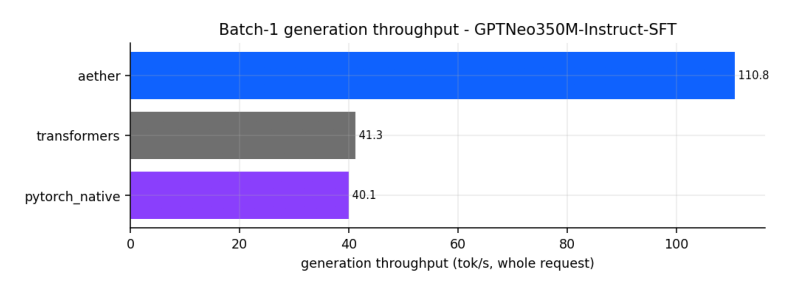

Displaying: /kaggle/working/benchmark_results/graphs/01_throughput_ranking__Qwen3-0.6B.png


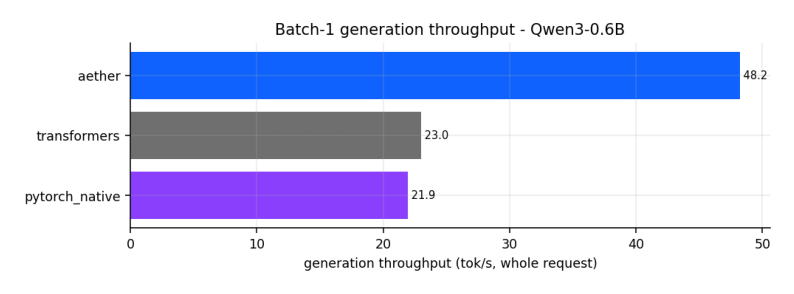

Displaying: /kaggle/working/benchmark_results/graphs/01_throughput_ranking__SmolLM2-135M-Instruct.png


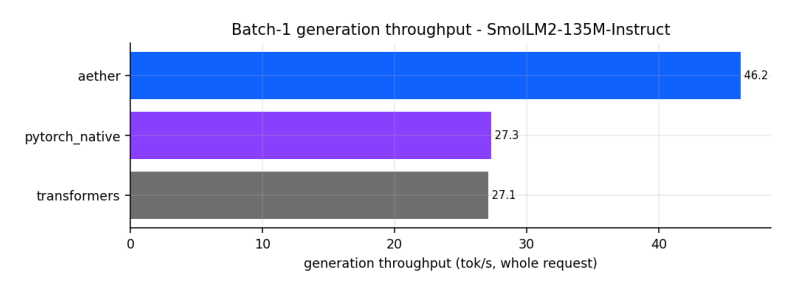

Displaying: /kaggle/working/benchmark_results/graphs/02_batch_scaling__GPTNeo350M-Instruct-SFT.png


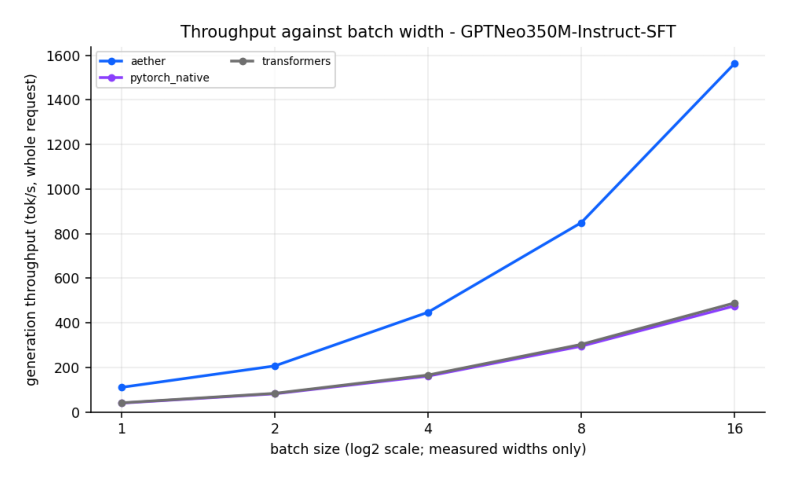

Displaying: /kaggle/working/benchmark_results/graphs/02_batch_scaling__Qwen3-0.6B.png


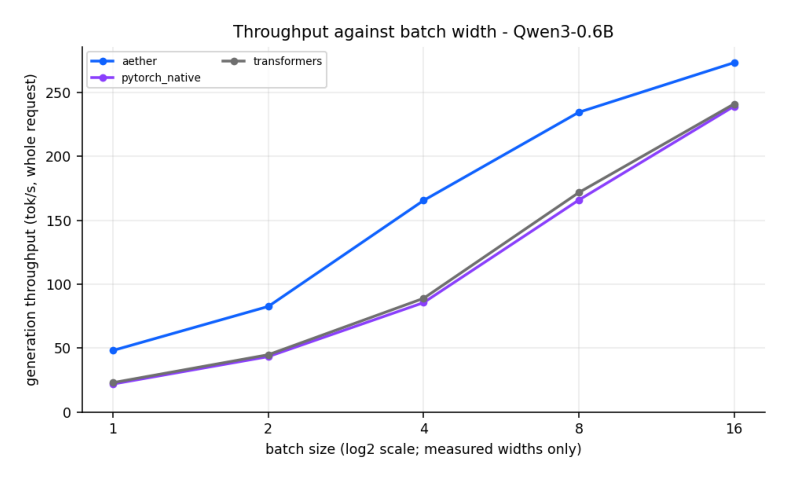

Displaying: /kaggle/working/benchmark_results/graphs/02_batch_scaling__SmolLM2-135M-Instruct.png


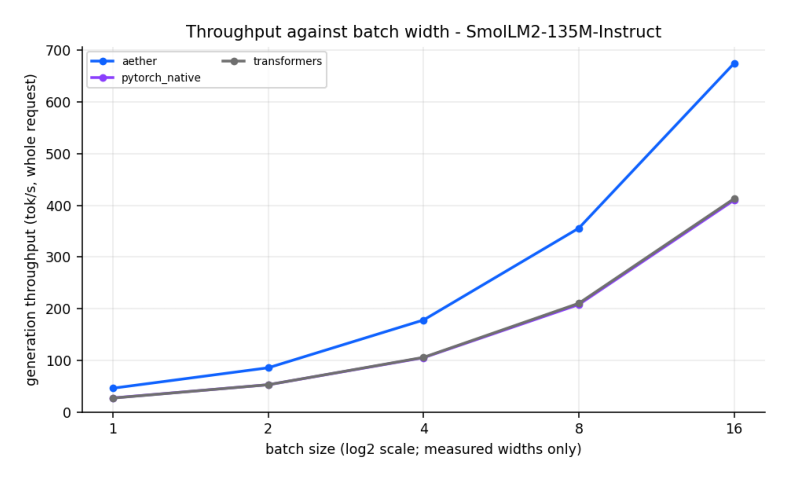

Displaying: /kaggle/working/benchmark_results/graphs/03_scaling_efficiency__GPTNeo350M-Instruct-SFT.png


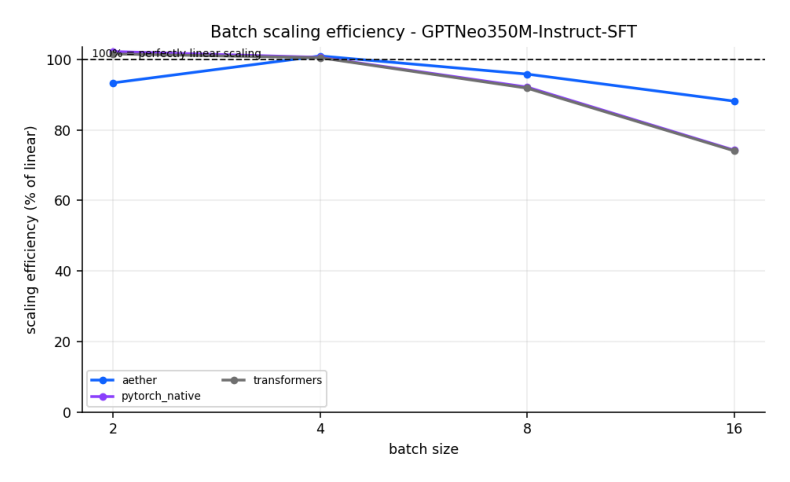

Displaying: /kaggle/working/benchmark_results/graphs/03_scaling_efficiency__Qwen3-0.6B.png


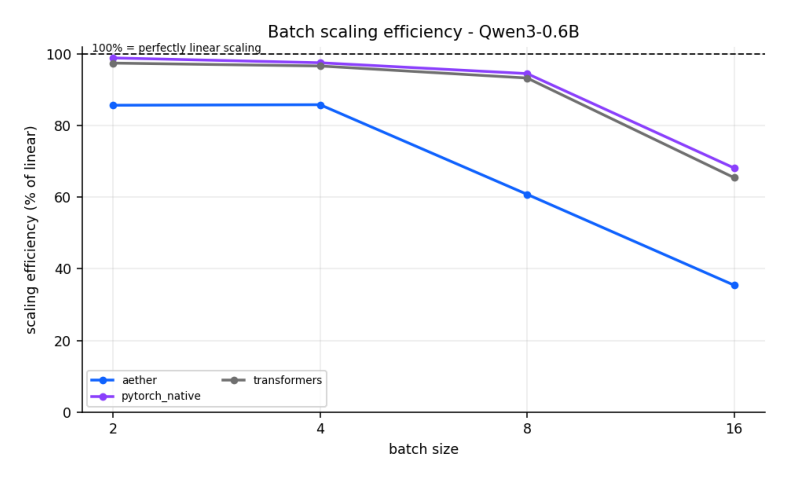

Displaying: /kaggle/working/benchmark_results/graphs/03_scaling_efficiency__SmolLM2-135M-Instruct.png


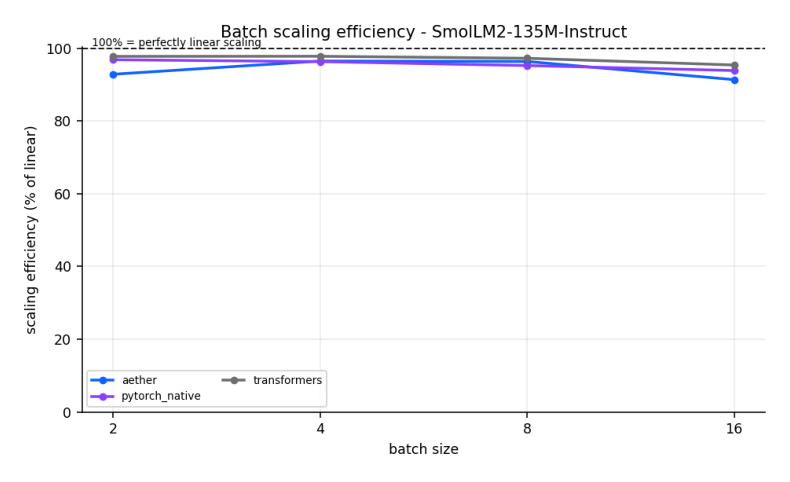

Displaying: /kaggle/working/benchmark_results/graphs/04_batch1__GPTNeo350M-Instruct-SFT.png


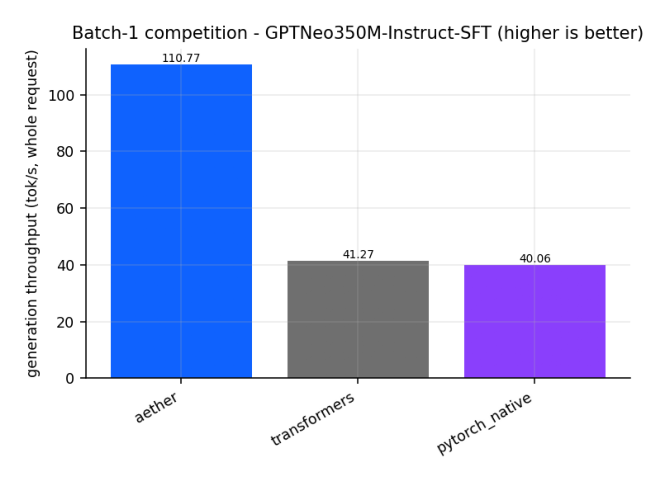

Displaying: /kaggle/working/benchmark_results/graphs/04_batch1__Qwen3-0.6B.png


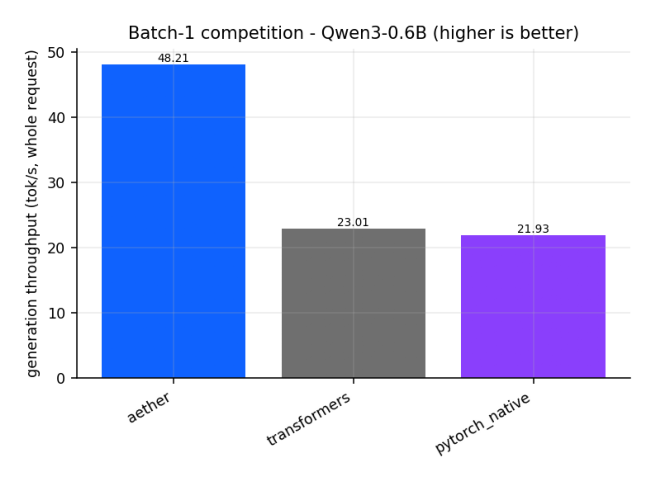

Displaying: /kaggle/working/benchmark_results/graphs/04_batch1__SmolLM2-135M-Instruct.png


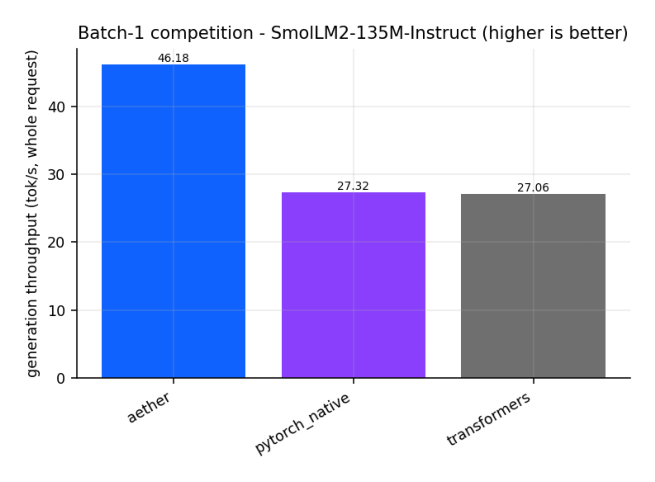

Displaying: /kaggle/working/benchmark_results/graphs/05_ttft__GPTNeo350M-Instruct-SFT.png


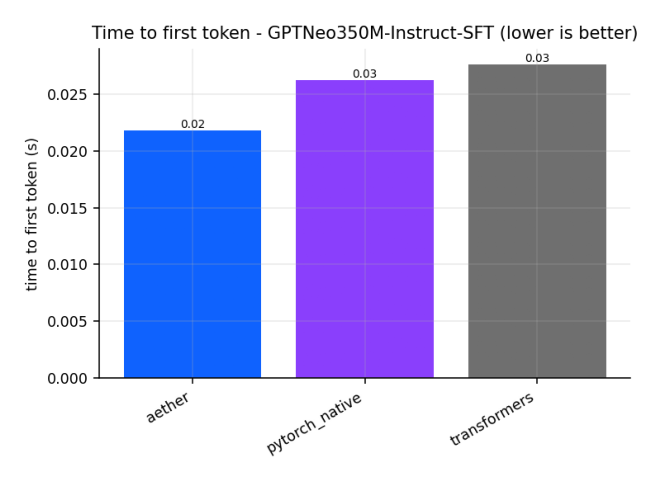

Displaying: /kaggle/working/benchmark_results/graphs/05_ttft__Qwen3-0.6B.png


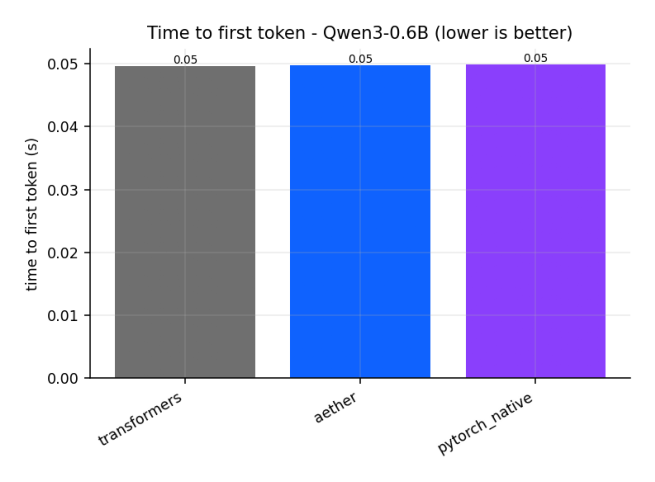

Displaying: /kaggle/working/benchmark_results/graphs/05_ttft__SmolLM2-135M-Instruct.png


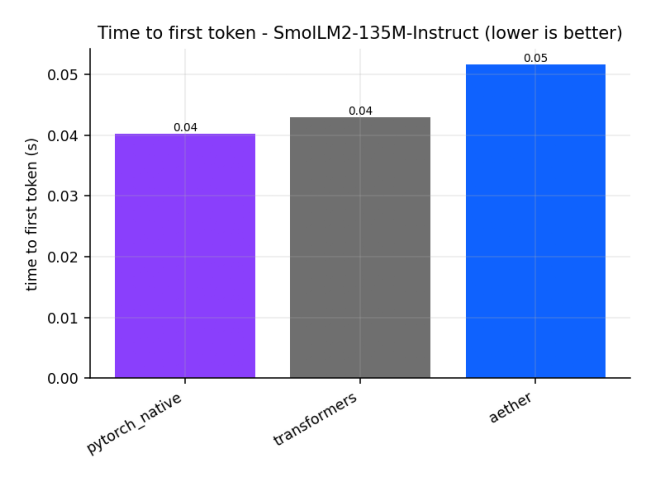

Displaying: /kaggle/working/benchmark_results/graphs/06_memory_host__GPTNeo350M-Instruct-SFT.png


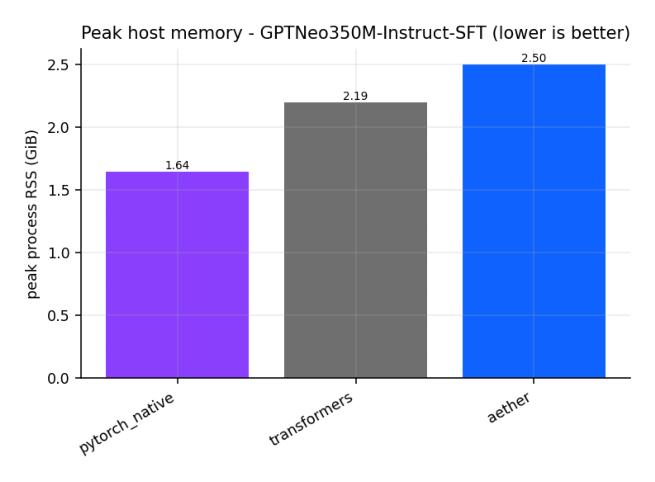

Displaying: /kaggle/working/benchmark_results/graphs/06_memory_host__Qwen3-0.6B.png


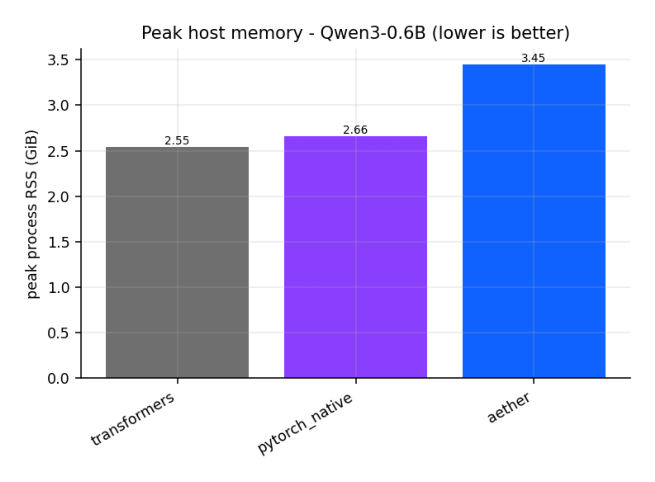

Displaying: /kaggle/working/benchmark_results/graphs/06_memory_host__SmolLM2-135M-Instruct.png


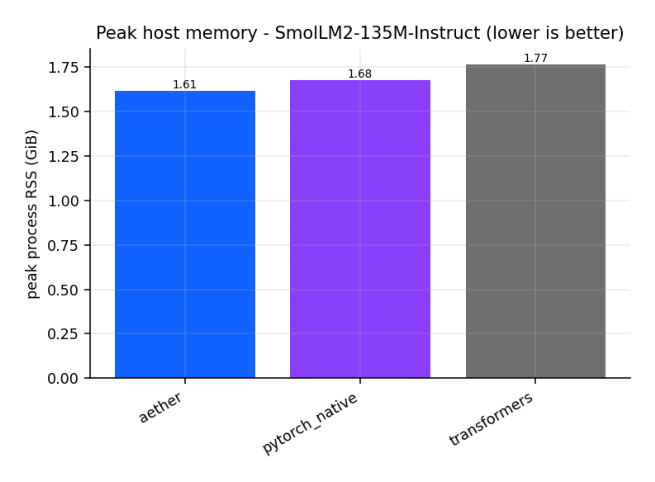

Displaying: /kaggle/working/benchmark_results/graphs/06b_memory_device__GPTNeo350M-Instruct-SFT.png


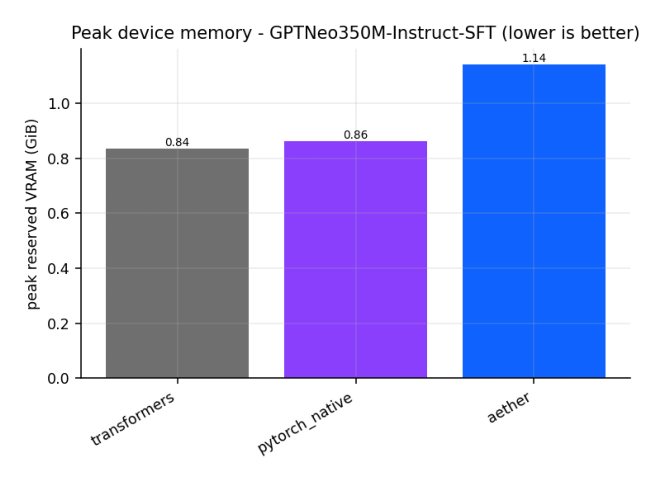

Displaying: /kaggle/working/benchmark_results/graphs/06b_memory_device__Qwen3-0.6B.png


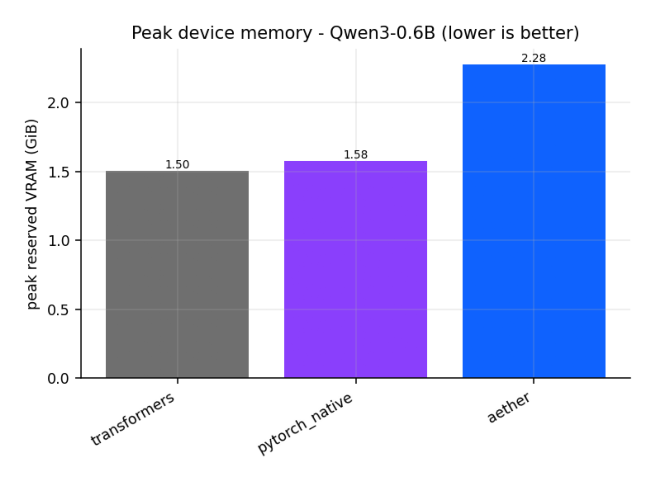

Displaying: /kaggle/working/benchmark_results/graphs/06b_memory_device__SmolLM2-135M-Instruct.png


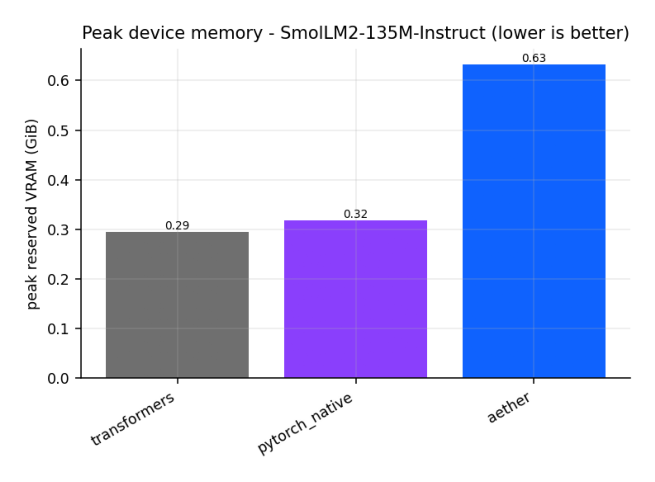

Displaying: /kaggle/working/benchmark_results/graphs/07_compile_tradeoff.png


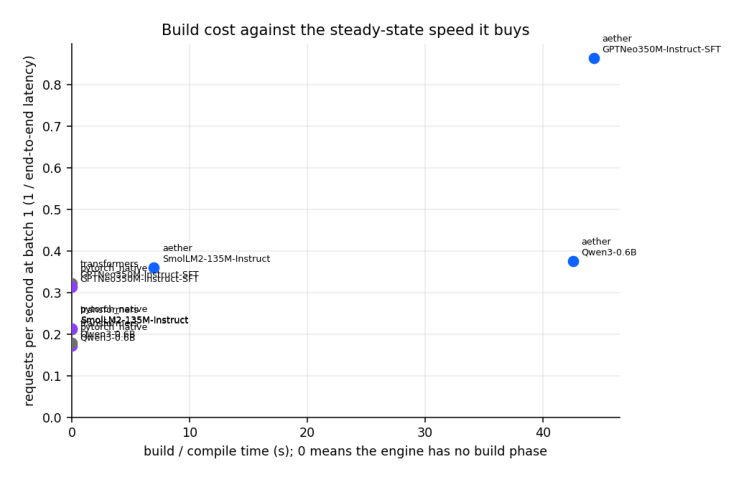

Displaying: /kaggle/working/benchmark_results/graphs/08_pairwise_matrix.png


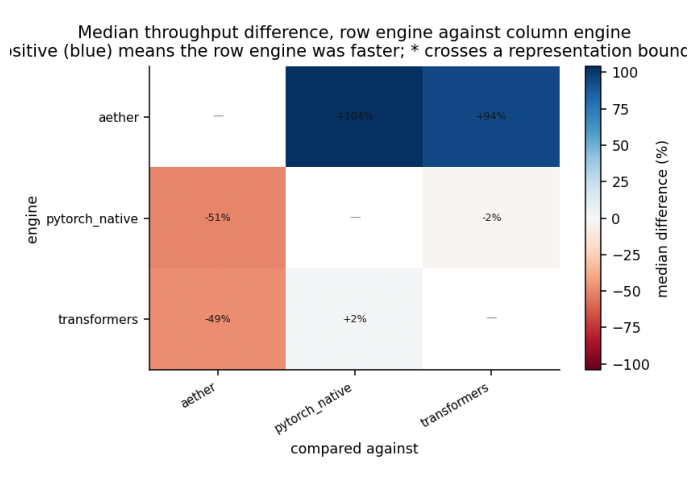

Displaying: /kaggle/working/benchmark_results/graphs/09_prompt_length__GPTNeo350M-Instruct-SFT.png


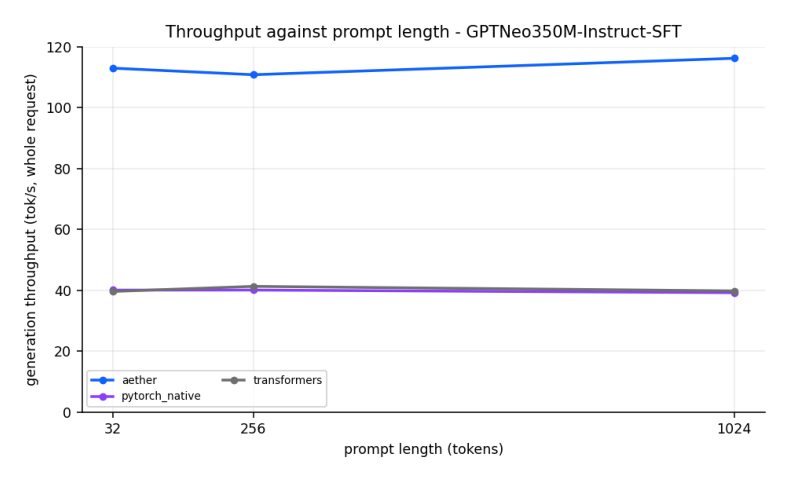

Displaying: /kaggle/working/benchmark_results/graphs/09_prompt_length__Qwen3-0.6B.png


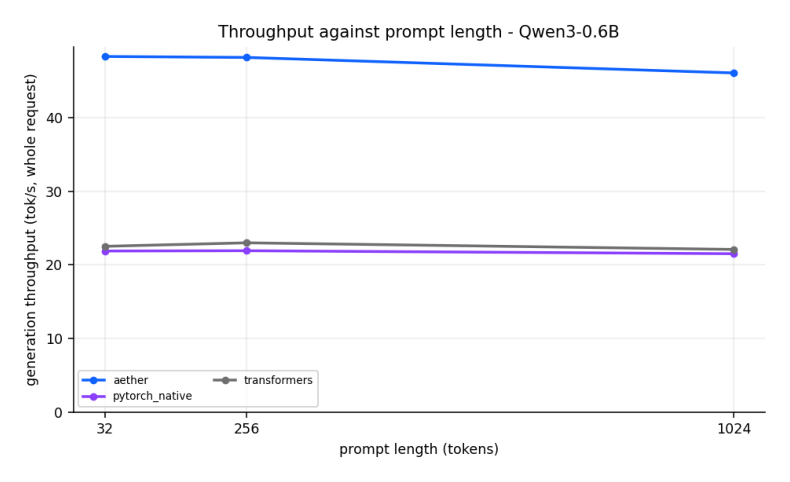

Displaying: /kaggle/working/benchmark_results/graphs/09_prompt_length__SmolLM2-135M-Instruct.png


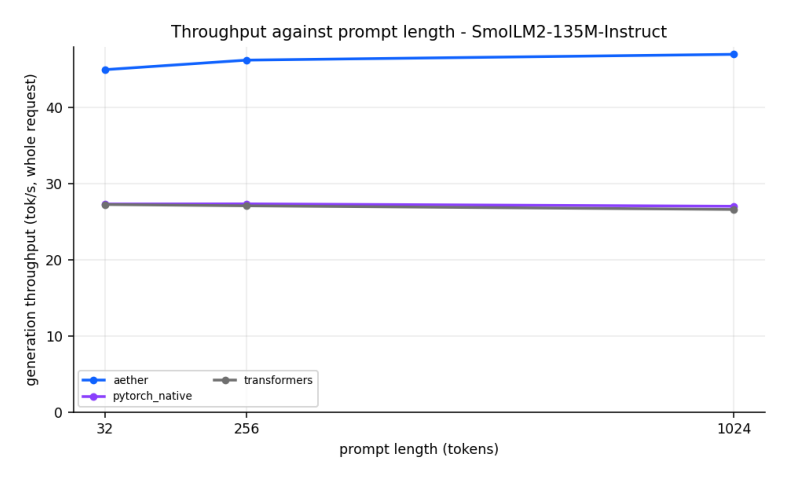

Displaying: /kaggle/working/benchmark_results/graphs/10_output_length__GPTNeo350M-Instruct-SFT.png


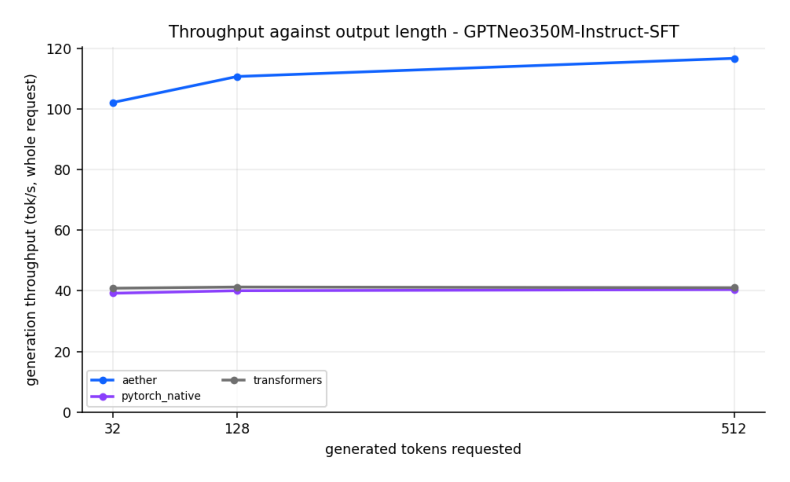

Displaying: /kaggle/working/benchmark_results/graphs/10_output_length__Qwen3-0.6B.png


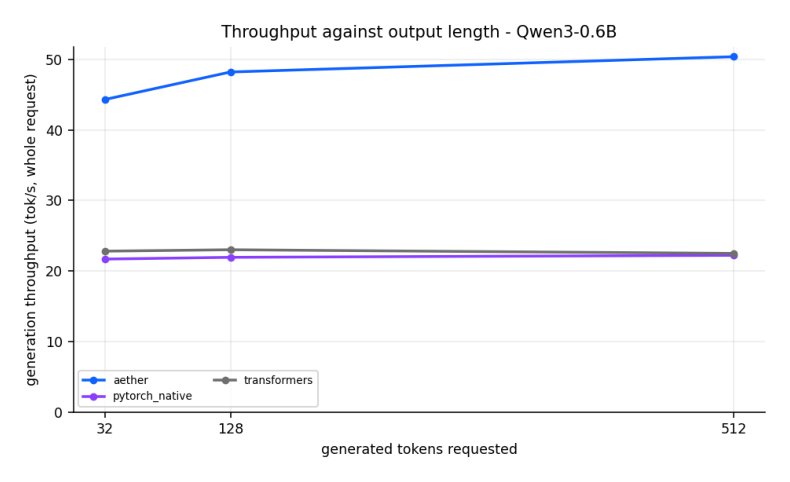

Displaying: /kaggle/working/benchmark_results/graphs/10_output_length__SmolLM2-135M-Instruct.png


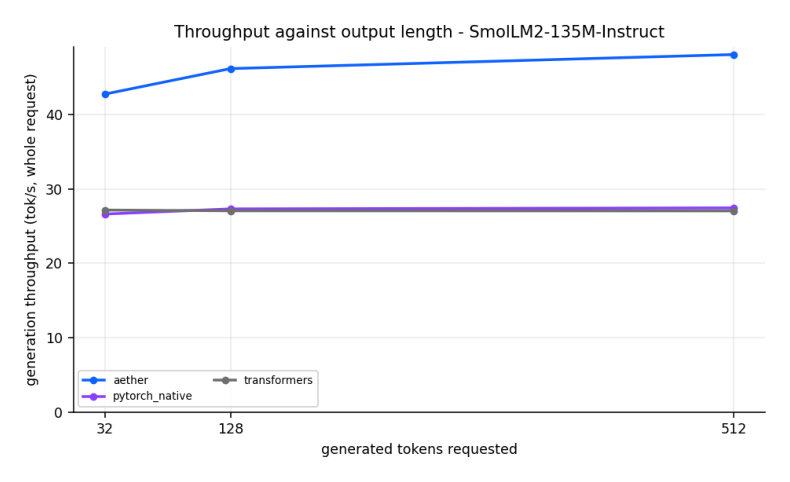

Displaying: /kaggle/working/benchmark_results/graphs/11_model_scaling.png


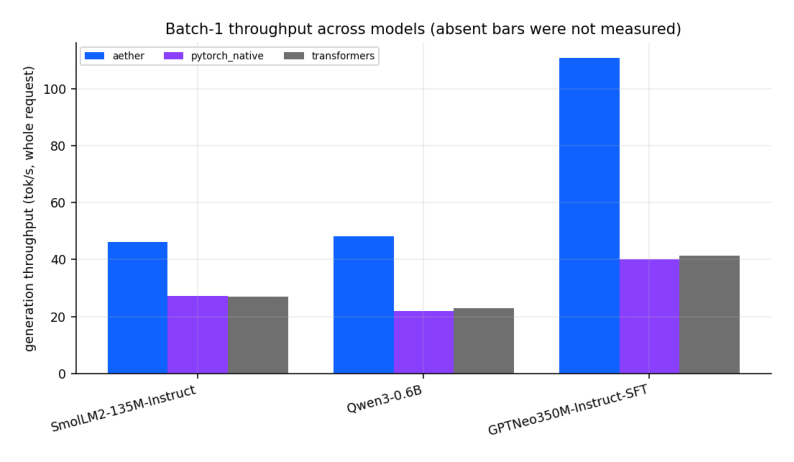

Displaying: /kaggle/working/benchmark_results/graphs/12_heatmap.png


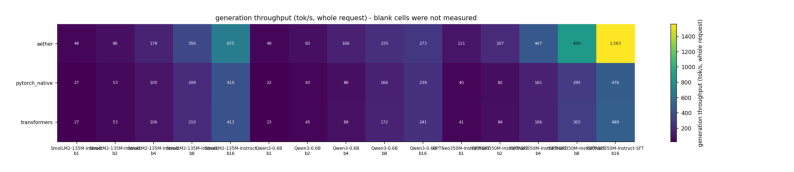

In [6]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

graph_dir = "/kaggle/working/benchmark_results/graphs"
charts = sorted(glob.glob(f"{graph_dir}/*.png"))

if not charts:
    charts = sorted(glob.glob("/kaggle/working/bench_smoke/graphs/*.png"))

print(f"Found {len(charts)} chart(s):")
for chart_path in charts:
    print(f"Displaying: {chart_path}")
    img = mpimg.imread(chart_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
